In [65]:
import random
import dill 
import datetime as dt
import glob 
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import pandas as pd
import scipy.spatial as spatial
import sys 
wd=".."
sys.path.append(wd+'//CPN//')
import numpy as np 
import statsmodels.api as sm
from tqdm import tqdm_notebook, tqdm
import brokenaxes
import math
import os
from analysis_misc_functions import *

In [66]:
results_folder = wd+"/simulations/effect_of_position_focal_bat_d/store_results/"
list_of_folder_ids= glob.glob(results_folder+"*")
list_of_folder_ids= [i[len(results_folder):] for i in list_of_folder_ids]
list_of_folder_ids= np.sort(list_of_folder_ids)
list_of_folder_ids_pruned= []
for folder_id in list_of_folder_ids:
    all_results = glob.glob(results_folder+str(folder_id)+'/*.simresults')
    if len(all_results)==0:
        continue
    list_of_folder_ids_pruned.append(folder_id)

list_of_folder_ids_array_version= [i.split(",") for i in list_of_folder_ids_pruned]
list_of_folder_ids_array_version= [(n[0][1:],n[1][:]) for n in list_of_folder_ids_array_version]
list_of_folder_ids_array_version= np.array([(float(n[0]), float(n[1])) for n in list_of_folder_ids_array_version])

group_sizes= [5,10,20,30,50,75]
list_of_folder_ids_array_version

array([[0.        , 0.        ],
       [1.        , 1.57079633],
       [1.        , 4.71238898],
       [2.        , 1.57079633],
       [2.        , 4.71238898],
       [3.        , 1.57079633],
       [3.        , 4.71238898],
       [4.        , 1.57079633],
       [4.        , 4.71238898],
       [5.        , 1.57079633],
       [5.        , 4.71238898],
       [6.        , 1.57079633],
       [6.        , 4.71238898]])

In [67]:
list_of_folder_ids

array(['(0, 0, 0.1)', '(1, 1.5707963267948966, 0.1)',
       '(1, 4.71238898038469, 0.1)', '(2, 1.5707963267948966, 0.1)',
       '(2, 4.71238898038469, 0.1)', '(3, 1.5707963267948966, 0.1)',
       '(3, 4.71238898038469, 0.1)', '(4, 1.5707963267948966, 0.1)',
       '(4, 4.71238898038469, 0.1)', '(5, 1.5707963267948966, 0.1)',
       '(5, 4.71238898038469, 0.1)', '(6, 1.5707963267948966, 0.1)',
       '(6, 4.71238898038469, 0.1)'], dtype='<U28')

In [68]:
list_of_folder_ids_array_version

array([[0.        , 0.        ],
       [1.        , 1.57079633],
       [1.        , 4.71238898],
       [2.        , 1.57079633],
       [2.        , 4.71238898],
       [3.        , 1.57079633],
       [3.        , 4.71238898],
       [4.        , 1.57079633],
       [4.        , 4.71238898],
       [5.        , 1.57079633],
       [5.        , 4.71238898],
       [6.        , 1.57079633],
       [6.        , 4.71238898]])

In [69]:
folder_id= list_of_folder_ids[0]
all_results = glob.glob(results_folder+folder_id+'/*.simresults')
some_results =random.sample(all_results, int(len(all_results)*1.0))
all_results

['../simulations/effect_of_position_focal_bat_d/store_results/(0, 0, 0.1)/focal_bat_d_915d04e4-7b23-410d-9a3f-036954a13470_950148687_.simresults',
 '../simulations/effect_of_position_focal_bat_d/store_results/(0, 0, 0.1)/focal_bat_d_9c848ed2-c24a-4d66-911a-fa39869ed10d_333596735_.simresults',
 '../simulations/effect_of_position_focal_bat_d/store_results/(0, 0, 0.1)/focal_bat_d_2eaf7a95-69f3-4518-8927-03b8bb77f7f5_696573139_.simresults',
 '../simulations/effect_of_position_focal_bat_d/store_results/(0, 0, 0.1)/focal_bat_d_2badef56-8fa1-4435-83bd-4169e021780d_326627109_.simresults',
 '../simulations/effect_of_position_focal_bat_d/store_results/(0, 0, 0.1)/focal_bat_d_7c6b3d4d-57ba-4556-a977-8b4a9ffd2a64_507644271_.simresults',
 '../simulations/effect_of_position_focal_bat_d/store_results/(0, 0, 0.1)/focal_bat_d_2ab93bc3-0582-49f5-8371-d0a6703f8e57_456395557_.simresults',
 '../simulations/effect_of_position_focal_bat_d/store_results/(0, 0, 0.1)/focal_bat_d_7a626bac-cfc2-411f-8787-a6cf86a4

In [70]:
extraction_fns = [get_num_echoes_heard, get_group_size, get_furthest_bat2bat_distance,
                 get_nearest_neighbour_distances, get_detection_distance, get_run_uuid,
                  get_run_random_seed,make_paramset_id, extract_parameter_values,
                 get_echo_levels, get_detection_azimuth]
keyword_arguments = {'nearest_nbrs':3}

In [71]:
keyword_arguments['variables_to_extract'] = ['heading_variation', 'echocall_duration','atmospheric_attenuation','min_spacing','source_level',
                        'interpulse_interval', 'implement_shadowing',
                                            ]

In [72]:
what_to_do = input('Do you want to "rerun" from scratch or 2, "reanalyse" from previous data')
task_type= input('What type of analysis is this?')

In [73]:
what_to_do

'rerun'

In [74]:
if what_to_do == 'rerun':
    array_containing_all_simulation_datasets_raw = []
    iterant=0
    yyyymmdd = dt.datetime.now()
    timestamp = str([yyyymmdd.year,yyyymmdd.month,yyyymmdd.day,yyyymmdd.hour])
    make_dir(task_type+'_data'+timestamp+"/")
    for folder_id in list_of_folder_ids_pruned:
        all_results = glob.glob(results_folder+str(folder_id)+'/*.simresults')
        some_results =random.sample(all_results, int(len(all_results)*1.0))
        if len(some_results)==0:
            continue
        
        %time extracted_simdata = Parallel(n_jobs=4)(delayed(load_and_extract)(each, extraction_fns, **keyword_arguments) for each in tqdm(some_results))
        # print(extracted_simdata)
        echoes_heard = []
        group_size = []
        group_diameter = []
        nearest_3nbrs = []
        nbr_detection_range = []
        uuid = []
        seed = []
        param_ids = []
        parameter_values = []
        echo_levels = []
        detection_angle = []
        for each in extracted_simdata:
            for variable, list_to_append in zip(each, [echoes_heard, group_size, group_diameter,
                                                    nearest_3nbrs, nbr_detection_range,
                                                    uuid, seed, param_ids, parameter_values,
                                                    echo_levels, detection_angle]):
                list_to_append.append(variable)
        simulation_data = pd.DataFrame(data = {'nbrs_detected':echoes_heard,
                                        'group_size':group_size,
                                        'group_diameter':group_diameter,
                                        'nearest_neighbour_distance':nearest_3nbrs,
                                        'nbrs_detected_distance':nbr_detection_range,
                                        'uuid':uuid,
                                        'seed':seed,
                                        'paramset_id':param_ids,
                                        'parameters_joint':parameter_values,
                                        'echo_levels':echo_levels,
                                        'detection_azimuth':detection_angle})
        column_names = keyword_arguments['variables_to_extract']

        for each in column_names:
            simulation_data[each] = np.nan

        %time simulation_data = simulation_data.apply(split_parameters_joint_to_separate_columns, 1, col_names=column_names)    
        

        simulation_data["focal_bat"]= len(simulation_data)*[list_of_folder_ids_array_version[iterant]]

        ##### thanks to https://realpython.com/fast-flexible-pandas/#but-i-heard-that-pandas-is-slow
        data_store = pd.HDFStore(task_type+'_data'+timestamp+'/'+folder_id+'.h5')
        data_store['simulation_data'] = simulation_data
        data_store.close()

        array_containing_all_simulation_datasets_raw.append(simulation_data)
        iterant+=1
        
if what_to_do == 'reanalyse':
    # show all datasets in the folder
    data_stores_in_folder = glob.glob(task_type+'_*]')

    datastores_by_index = pd.DataFrame(data={'data_stores':data_stores_in_folder})
    print(datastores_by_index)
    # user-inputs dataset choice:
    which_dataset = int(input('Give the index of the dataset you want to'))
    print()
    # load a pre-exisiting dataset
    #load the saved data 
    list_of_h5_files_in_folder= making_glob_work_properly(datastores_by_index["data_stores"][which_dataset])
    # print(list_of_h5_files_in_folder); print("./"+datastores_by_index["data_stores"][which_dataset]+'/*')
    array_containing_all_simulation_datasets_raw = []
    list_of_folder_ids_pruned, list_of_folder_ids_array_version= run_while_reanalysis_to_change_folder_ids(list_of_h5_files_in_folder)
    for h5_file in list_of_h5_files_in_folder:
        data_load = pd.HDFStore("./"+datastores_by_index["data_stores"][which_dataset]+'/'+h5_file)
        simulation_data = data_load['simulation_data']
        array_containing_all_simulation_datasets_raw.append(simulation_data)
        data_load.close()

# else:
#     raise IOError('Invalid input given!!')

100%|██████████| 600/600 [00:01<00:00, 518.74it/s]
/tmp/ipykernel_916215/3001290290.py:55: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth',
       'focal_bat'],
      dtype='object')]

  data_store['simulation_data'] = simulation_data


CPU times: user 49.9 ms, sys: 7.15 ms, total: 57.1 ms
Wall time: 1.38 s
CPU times: user 32.5 ms, sys: 6 μs, total: 32.5 ms
Wall time: 32.5 ms


100%|██████████| 600/600 [00:00<00:00, 1605.43it/s]
/tmp/ipykernel_916215/3001290290.py:55: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth',
       'focal_bat'],
      dtype='object')]

  data_store['simulation_data'] = simulation_data


CPU times: user 54.9 ms, sys: 4.86 ms, total: 59.7 ms
Wall time: 620 ms
CPU times: user 33.7 ms, sys: 0 ns, total: 33.7 ms
Wall time: 33.7 ms


100%|██████████| 600/600 [00:00<00:00, 1611.98it/s]
/tmp/ipykernel_916215/3001290290.py:55: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth',
       'focal_bat'],
      dtype='object')]

  data_store['simulation_data'] = simulation_data


...

CPU times: user 20.6 ms, sys: 3.97 ms, total: 24.6 ms
Wall time: 233 ms
CPU times: user 11.5 ms, sys: 13 μs, total: 11.5 ms
Wall time: 11.5 ms


100%|██████████| 100/100 [00:00<00:00, 1539.84it/s]
/tmp/ipykernel_916215/3001290290.py:55: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth',
       'focal_bat'],
      dtype='object')]

  data_store['simulation_data'] = simulation_data


CPU times: user 13.2 ms, sys: 1.14 ms, total: 14.3 ms
Wall time: 124 ms
CPU times: user 5.57 ms, sys: 24 μs, total: 5.59 ms
Wall time: 5.59 ms


100%|██████████| 100/100 [00:00<00:00, 1528.41it/s]
/tmp/ipykernel_916215/3001290290.py:55: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth',
       'focal_bat'],
      dtype='object')]

  data_store['simulation_data'] = simulation_data


CPU times: user 13.2 ms, sys: 4.06 ms, total: 17.3 ms
Wall time: 123 ms
CPU times: user 5.63 ms, sys: 0 ns, total: 5.63 ms
Wall time: 5.6 ms


In [75]:
array_containing_all_simulation_datasets_pruned= []
for group_size in group_sizes:
    for simulation_data in array_containing_all_simulation_datasets_raw:
        indices_given_group_size= simulation_data["group_size"]==group_size
        if len(simulation_data[indices_given_group_size])<100:
            array_containing_all_simulation_datasets_pruned.append(simulation_data[~indices_given_group_size])

In [76]:
array_containing_all_simulation_datasets=[]

for simulation_data in array_containing_all_simulation_datasets_raw:
    if False: #simulation_data["focal_bat"][0][0]==5.0 or simulation_data["focal_bat"][0][0]==6.0:
        continue
    else:
        array_containing_all_simulation_datasets.append(simulation_data)



In [77]:
array_containing_all_simulation_datasets

[     nbrs_detected  group_size  group_diameter  \
 0                1          10        1.978026   
 1                4          20        2.882062   
 2                0          75        6.074625   
 3                3          50        5.035896   
 4                6          20        2.962570   
 ..             ...         ...             ...   
 595              1          75        5.953697   
 596              0          75        6.167275   
 597              8          10        1.970761   
 598              9          10        2.288785   
 599              0          75        6.086686   
 
                             nearest_neighbour_distance  \
 0    [0.5428736947353339, 0.587185265828405, 0.6179...   
 1    [0.645049173188116, 0.6458799259968936, 0.6487...   
 2    [0.5053724063053979, 0.511034893108874, 0.5200...   
 3    [0.6100839105521718, 0.6522483894563219, 0.730...   
 4    [0.5294128727015872, 0.572572606612555, 0.6476...   
 ..                             

In [78]:
unique_angles_in_dataset= np.unique(list_of_folder_ids_array_version[:,1])
list_containing_simulated_data_sorted_by_angles= {}
for angle in unique_angles_in_dataset:
    list_containing_simulated_data_sorted_by_angles[angle]= []
    sublist_true_false_labels= list_of_folder_ids_array_version[:,1]==angle
    sublist_given_angle= passing_true_false_indices_through_lists(array_containing_all_simulation_datasets_raw, sublist_true_false_labels)
    list_containing_simulated_data_sorted_by_angles[angle].append(sublist_given_angle)

0
1
3
5
7
9
11
2
4
6
8
10
12


0.0


/tmp/ipykernel_916215/2100935761.py:9: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(simulation_data['group_size'],


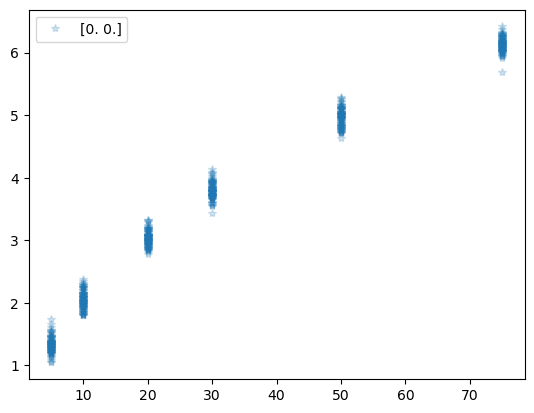

1.5707963267948966


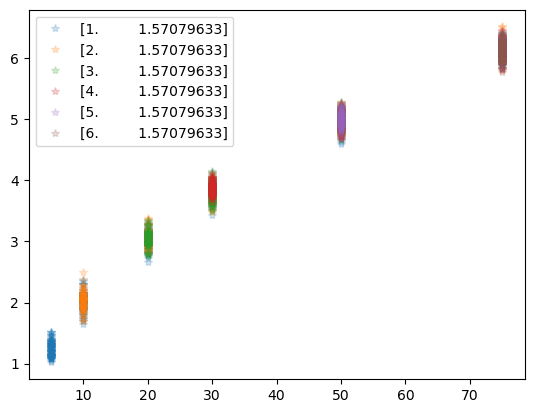

4.71238898038469


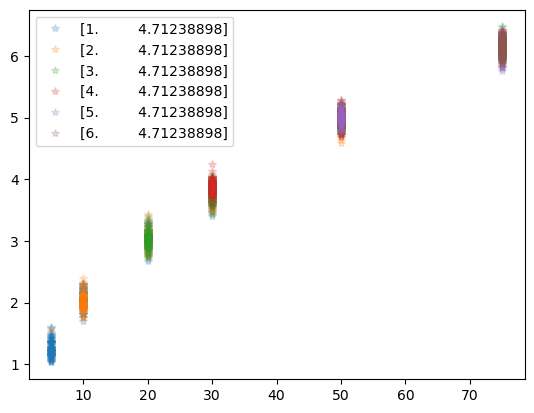

In [79]:
%matplotlib inline
i=0
for angle in list_containing_simulated_data_sorted_by_angles.keys():
    print(angle)
    subset_given_angle= list_containing_simulated_data_sorted_by_angles[angle][0]

    for simulation_data in subset_given_angle:
        if len(simulation_data)!=0:
            plt.plot(simulation_data['group_size'],
                        simulation_data['group_diameter'], 
                    '*',label=simulation_data["focal_bat"][0],alpha=0.2)
        i+=1
    plt.legend()
    plt.show()

In [80]:
simulation_data.keys()

Index(['nbrs_detected', 'group_size', 'group_diameter',
       'nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid', 'seed',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth',
       'heading_variation', 'echocall_duration', 'atmospheric_attenuation',
       'min_spacing', 'source_level', 'interpulse_interval',
       'implement_shadowing', 'focal_bat'],
      dtype='object')

In [81]:
by_minspacing = simulation_data.groupby('min_spacing')
nearest_nbr_dist = {}
for spacing, df in by_minspacing:
    nearest_nbr_distances = df['nearest_neighbour_distance'].reset_index(drop=True)
    nearest_nbr_dist[spacing] = np.concatenate(nearest_nbr_distances)
nearest_nbr_dists_for_plot = [nearest_nbr_dist[0.5]]

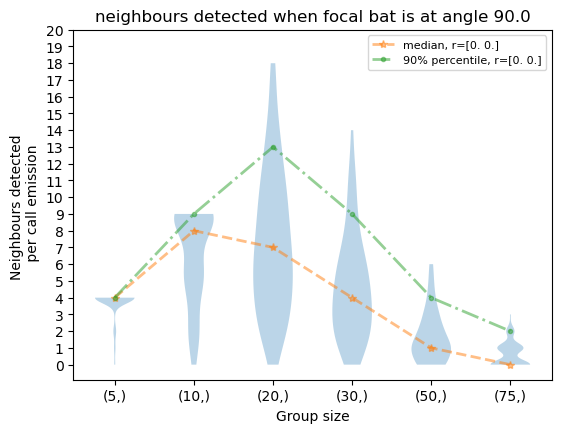

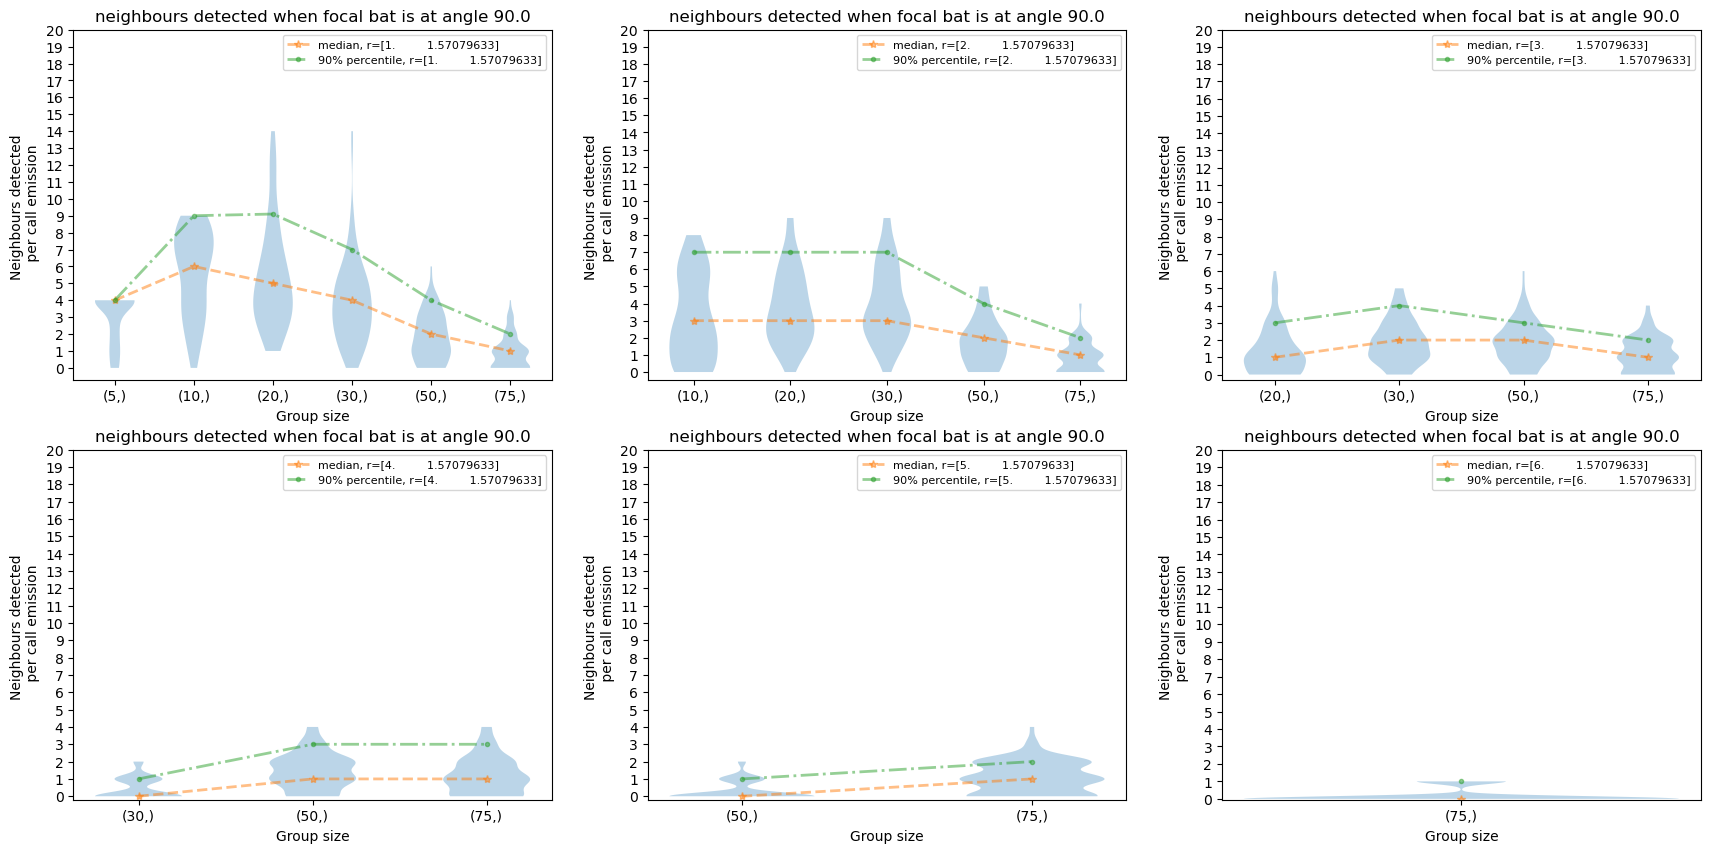

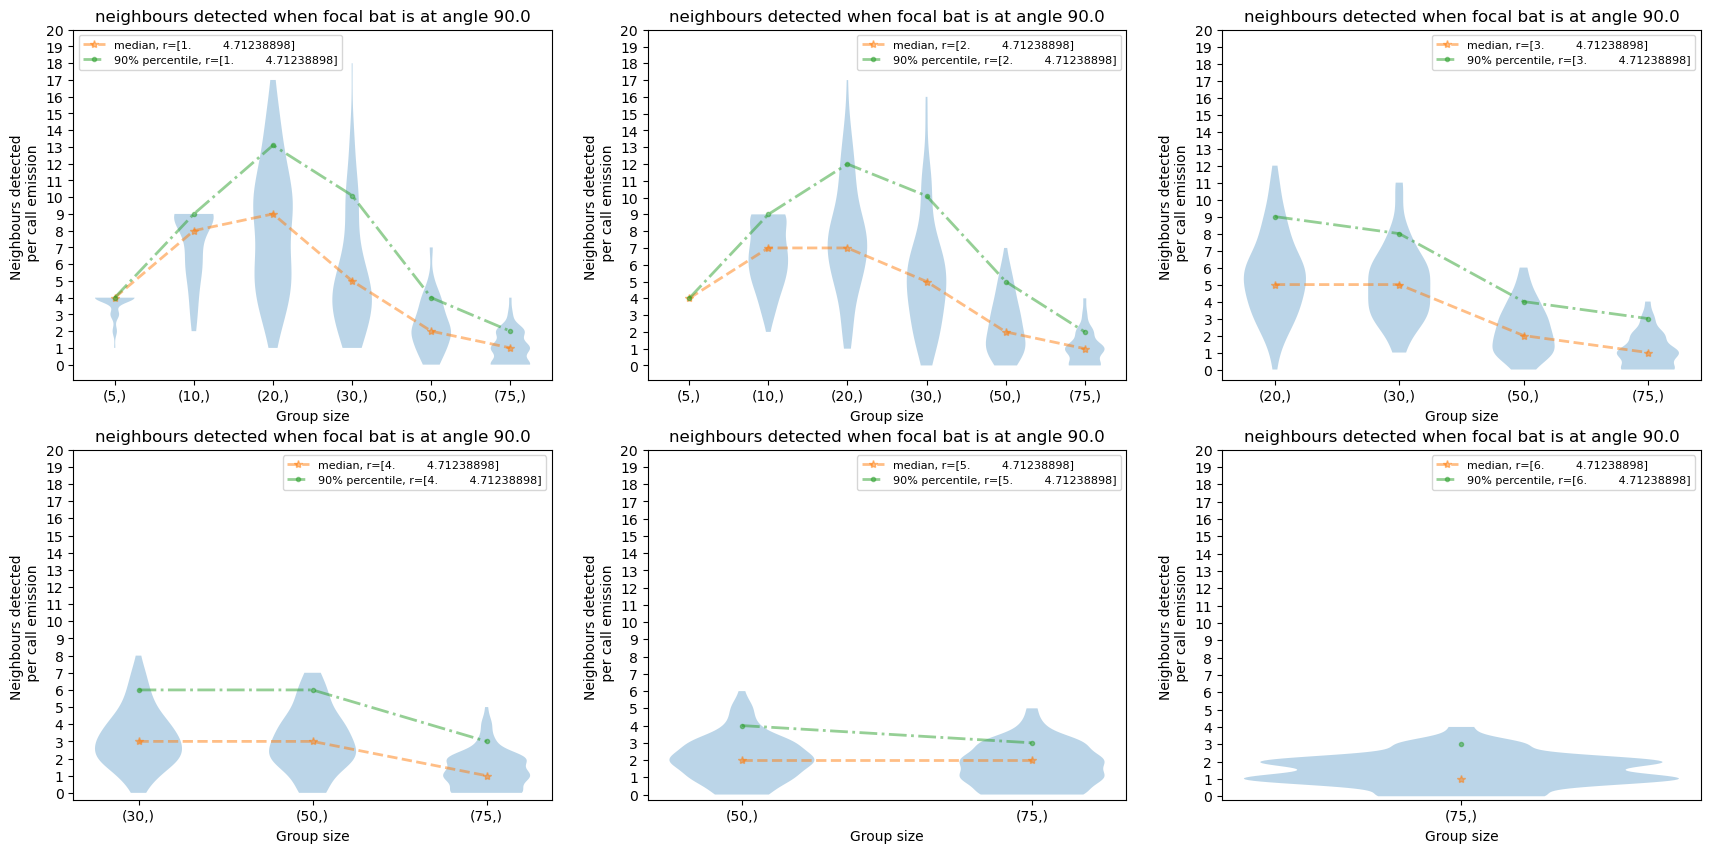

In [82]:
iterant1_axis=0
# fig, axs = plt.subplots(1,3, figsize=(27,9))


for angle in list_containing_simulated_data_sorted_by_angles.keys():
        subset_given_angle= list_containing_simulated_data_sorted_by_angles[angle][0]; iterant2_color=0
        colors=["blue", "red", "green", "black"]
        plt.figure(figsize=(21,10))
        i=1
        for simulation_data in subset_given_angle:
                data_by_groupsize = simulation_data.groupby(['group_size'])
                nbrs_detected_data = {}
                nbrs_detected_data['num_nbrs'] = []
                nbrs_detected_data['median_num_nbrs'] = []
                nbrs_detected_data['90%ile_num_nbrs'] = []
                groupsizes= []
                for groupsize, dataframe in data_by_groupsize:
                        groupsizes.append(groupsize)
                        nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
                        nbrs_detected_data['median_num_nbrs'].append(np.median(np.array(dataframe['nbrs_detected'])))
                        nbrs_detected_data['90%ile_num_nbrs'].append(np.percentile(np.array(dataframe['nbrs_detected']), 90))

                breakup_x_axis  = np.arange(1,len(groupsizes)+1)+0.5
                nbrs_detected_data['median_num_nbrs']

                # plt.figure(figsize=(7,3.42))
                plt.subplot(2,3,i)
                plt.violinplot(nbrs_detected_data['num_nbrs'][:], showextrema=False)
                plt.plot(np.arange(1,len(groupsizes)+1),nbrs_detected_data['median_num_nbrs'][:],
                        '--*',linewidth=2, alpha=0.5,label="median, r="+str(simulation_data["focal_bat"][0]))#'median')
                # print(np.arange(1,len(groupsizes)))
                plt.plot(np.arange(1,len(groupsizes)+1), nbrs_detected_data['90%ile_num_nbrs'][:],
                        '-..',linewidth=2, alpha=0.5, label="90% percentile, r="+str(simulation_data["focal_bat"][0]))#label='90%ile')
                # plt.vlines(breakup_x_axis, -1,20, 'w',linewidth=30,alpha=1.0)
                plt.yticks(np.arange(0,21,1))
                plt.xticks(range(1,len(groupsizes)+1),groupsizes[:])
                plt.legend(fontsize=8)
                plt.ylabel('Neighbours detected \n per call emission', fontsize=10)
                plt.xlabel('Group size', fontsize=10)
                # # plt.ylim(0,20)

                # axs[i].tight_layout()
                plt.title("neighbours detected when focal bat is at angle "+str(np.degrees(np.pi/2)))
                iterant2_color+=1; i+=1
                
        iterant1_axis+=1
                # plt.savefig('Figure2_groupsize_1200dpi.pdf',
                #         bbox_inches='tight', pad_inches=0.05, format='pdf', dpi=1200)
        
        # print(groupsizes); print(nbrs_detected_data['median_num_nbrs'])

# Verticle transect

moving from $(0.75, \frac {3pi}{2})$ to $(0.75, \frac {pi}{2})$ [r, theta] is similar to moving in a ($x=0$) transect centered at the centermost bat.
Note: All the heading vectors are in 90 degree direction ( $\pm$ 10 degree)

In [129]:
transect_subsets= [[6, 3*np.pi/2],[5, 3*np.pi/2],[4, 3*np.pi/2],[3, 3*np.pi/2],[2, 3*np.pi/2],[1, 3*np.pi/2],[0.0,0.0],[1, np.pi/2],[2, np.pi/2], [3, np.pi/2], [4, np.pi/2], [5, np.pi/2], [6, np.pi/2]]
iterant_transect=0
sublist_of_simulation_data_intransect=[]
for r_theta in transect_subsets:
    for simulation_data in array_containing_all_simulation_datasets:
        if (simulation_data["focal_bat"][0]==r_theta).all():
            sublist_of_simulation_data_intransect.append(simulation_data)    

sign_based_on_distance_from_centermost_point= [-1, -1, -1, -1, -1, -1,0, 1, 1, 1, 1, 1, 1]     


In [130]:
len(sublist_of_simulation_data_intransect)
# len(transect_subsets)

13

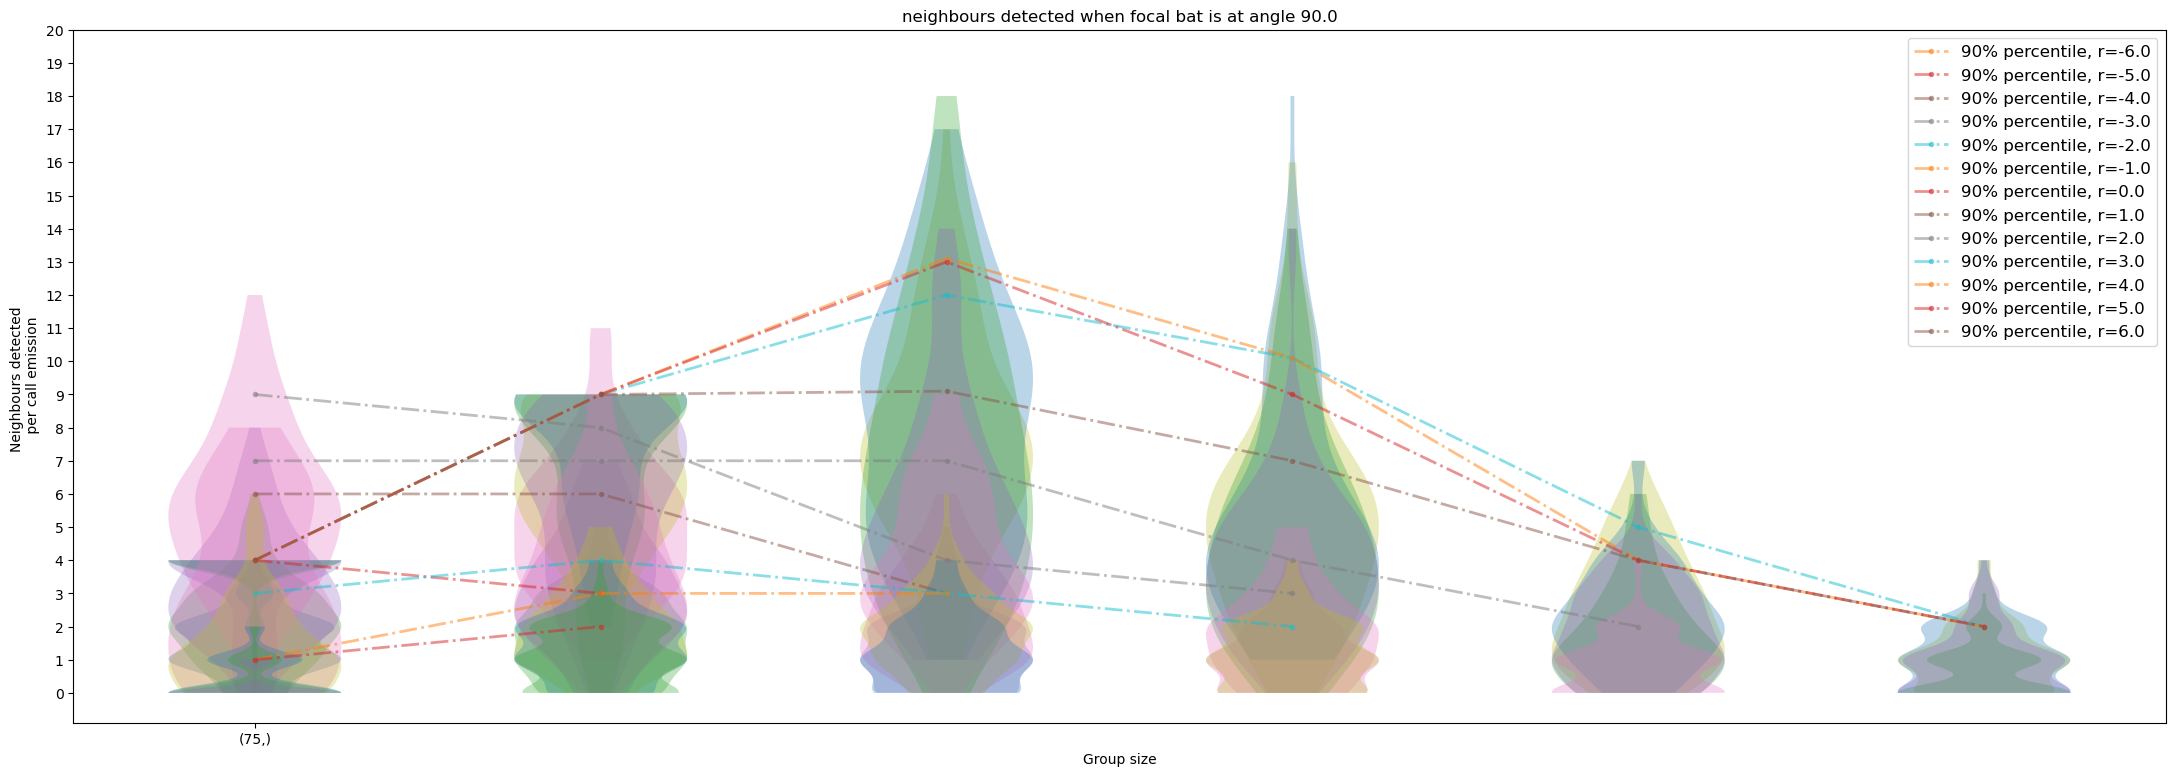

In [131]:
colors=["blue", "red", "green", "black", "orange", "cyan"]

fig, axs = plt.subplots(1,1, figsize=(27,9))
iterant2_color=0
for simulation_data in sublist_of_simulation_data_intransect:
        data_by_groupsize = simulation_data.groupby(['group_size'])
        nbrs_detected_data = {}
        nbrs_detected_data['num_nbrs'] = []
        nbrs_detected_data['median_num_nbrs'] = []
        nbrs_detected_data['90%ile_num_nbrs'] = []
        groupsizes= []
        for groupsize, dataframe in data_by_groupsize:
                groupsizes.append(groupsize)
                nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
                nbrs_detected_data['median_num_nbrs'].append(np.median(np.array(dataframe['nbrs_detected'])))
                nbrs_detected_data['90%ile_num_nbrs'].append(np.percentile(np.array(dataframe['nbrs_detected']), 90))

        breakup_x_axis  = np.arange(1,len(groupsizes)+1)+0.5
        nbrs_detected_data['median_num_nbrs']

        # plt.figure(figsize=(7,3.42))
        # plt.subplot(1,2,i)
        
        axs.violinplot(nbrs_detected_data['num_nbrs'][:], showextrema=False)
        # axs.plot(np.arange(1,len(groupsizes)+1),nbrs_detected_data['median_num_nbrs'][:],
        #         '--*',linewidth=2, alpha=0.5,label="median, r="+str(sign_based_on_distance_from_centermost_point[iterant2_color]*simulation_data["focal_bat"][0][0]), 
        #         color= colors[iterant2_color])#'median')
        # print(np.arange(1,len(groupsizes)))
        axs.plot(np.arange(1,len(groupsizes)+1), nbrs_detected_data['90%ile_num_nbrs'][:],
                '-..',linewidth=2, alpha=0.5, label="90% percentile, r="+str(sign_based_on_distance_from_centermost_point[iterant2_color]*simulation_data["focal_bat"][0][0])
                )#label='90%ile')
        # plt.vlines(breakup_x_axis, -1,20, 'w',linewidth=30,alpha=1.0)
        axs.set_yticks(np.arange(0,21,1))
        axs.set_xticks(range(1,len(groupsizes)+1),groupsizes[:])
        axs.legend(fontsize=12)
        axs.set_ylabel('Neighbours detected \n per call emission', fontsize=10)
        axs.set_xlabel('Group size', fontsize=10)
        # # plt.ylim(0,20)

        # axs[i].tight_layout()
        axs.set_title("neighbours detected when focal bat is at angle "+str(np.degrees(simulation_data["focal_bat"][0][1])))
        iterant2_color+=1
plt.show()

separate the violin plots out for different group sizes to see clear differences between distance from center


/tmp/ipykernel_916215/721828577.py:18: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  dataframe = simulation_data.groupby(['group_size']).get_group(group_size)
/tmp/ipykernel_916215/721828577.py:18: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  dataframe = simulation_data.groupby(['group_size']).get_group(group_size)
/tmp/ipykernel_916215/721828577.py:18: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  dataframe = simulation_data.groupby(['group_size']).get_group(group_size)
/tmp/ipykernel_916215/721828577.py:18: FutureWarning: When group

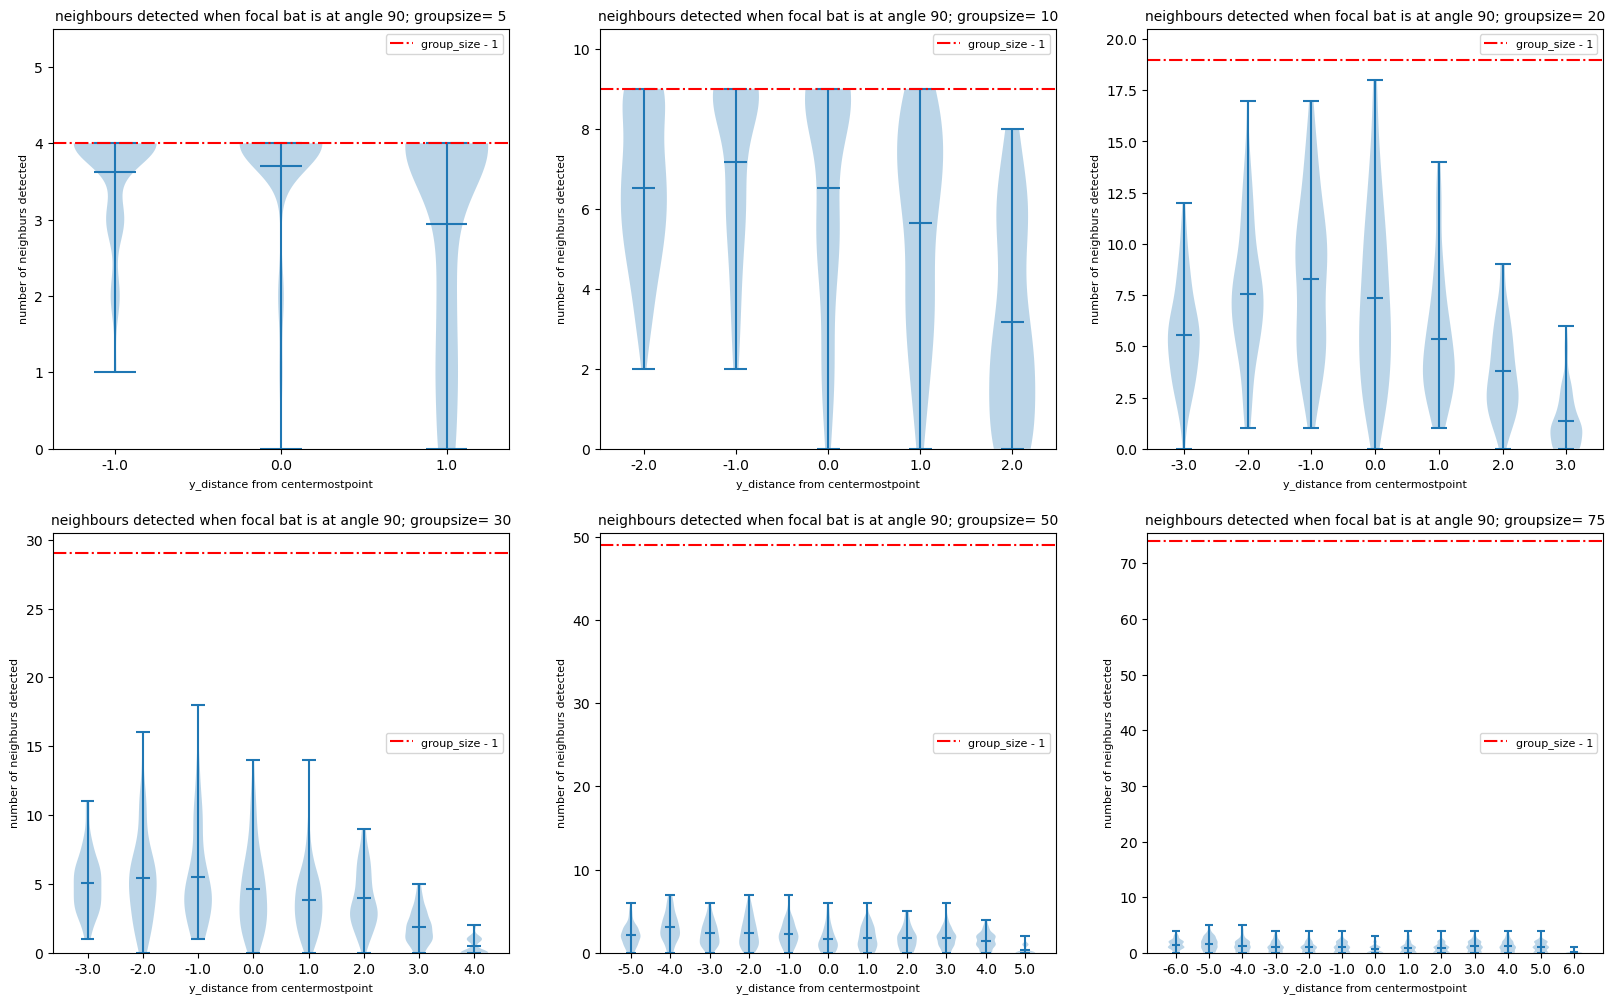

In [132]:
colors=["blue", "red", "green", "black", "pink", "cyan", "yellow"]

# fig, axs = plt.subplots(1,1, figsize=(27,9))
i=0; 
number_of_columns=3; number_of_rows= int(np.ceil(len(group_sizes)/number_of_columns))
plt.figure(figsize=(20,12))
for group_size in group_sizes:
    nbrs_detected_data = {}
    nbrs_detected_data['num_nbrs'] = []
    nbrs_detected_data['median_num_nbrs'] = []
    nbrs_detected_data['90%ile_num_nbrs'] = []
    
    x_ticks= []; iterant_sign=-1
    for simulation_data in sublist_of_simulation_data_intransect:
        iterant_sign+=1

        try:
            dataframe = simulation_data.groupby(['group_size']).get_group(group_size)    
            if len(dataframe["nbrs_detected"])!=100:
                continue
            nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
            nbrs_detected_data['median_num_nbrs'].append(np.median(np.array(dataframe['nbrs_detected'])))
            nbrs_detected_data['90%ile_num_nbrs'].append(np.percentile(np.array(dataframe['nbrs_detected']), 90))    
        except KeyError:
            continue
        x_ticks.append(sign_based_on_distance_from_centermost_point[iterant_sign]*simulation_data["focal_bat"][0][0])
    

    plt.subplot(number_of_rows,number_of_columns,i+1)
    plt.violinplot(nbrs_detected_data['num_nbrs'], showmeans=True)
    # plt.boxplot(nbrs_detected_data['num_nbrs'], showmeans=True)
    plt.title(f"neighbours detected when focal bat is at angle {90}; groupsize= {group_size}", fontsize= "10")
    plt.xticks(np.arange(1,len(x_ticks)+1),x_ticks)
    # plt.show()
    plt.ylim(0,group_size+0.5)
    plt.axhline(group_size-1, ls="-.", color="red", label= "group_size - 1")
    plt.xlabel("y_distance from centermostpoint", fontsize= "8")
    plt.ylabel("number of neighburs detected", fontsize= "8")
    plt.legend(fontsize= "8")

    i+=1

Zooming into the plots to see finer differences between the diffrent violin plots

In [155]:
colors=["blue", "red", "green", "black", "pink", "cyan", "yellow"]

In [ ]:
# import matplotlib

# cmap = matplotlib.cm.get_cmap('Spectral')
# colors= np.arange(0.1, 1, (1-0.1)/7)
# colors= [cmap(i) for i in colors]

/tmp/ipykernel_916215/2921445900.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('Spectral')


/tmp/ipykernel_916215/2747149107.py:17: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  dataframe = simulation_data.groupby(['group_size']).get_group(group_size)
/tmp/ipykernel_916215/2747149107.py:17: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  dataframe = simulation_data.groupby(['group_size']).get_group(group_size)
/tmp/ipykernel_916215/2747149107.py:17: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  dataframe = simulation_data.groupby(['group_size']).get_group(group_size)
/tmp/ipykernel_916215/2747149107.py:17: FutureWarning: When g

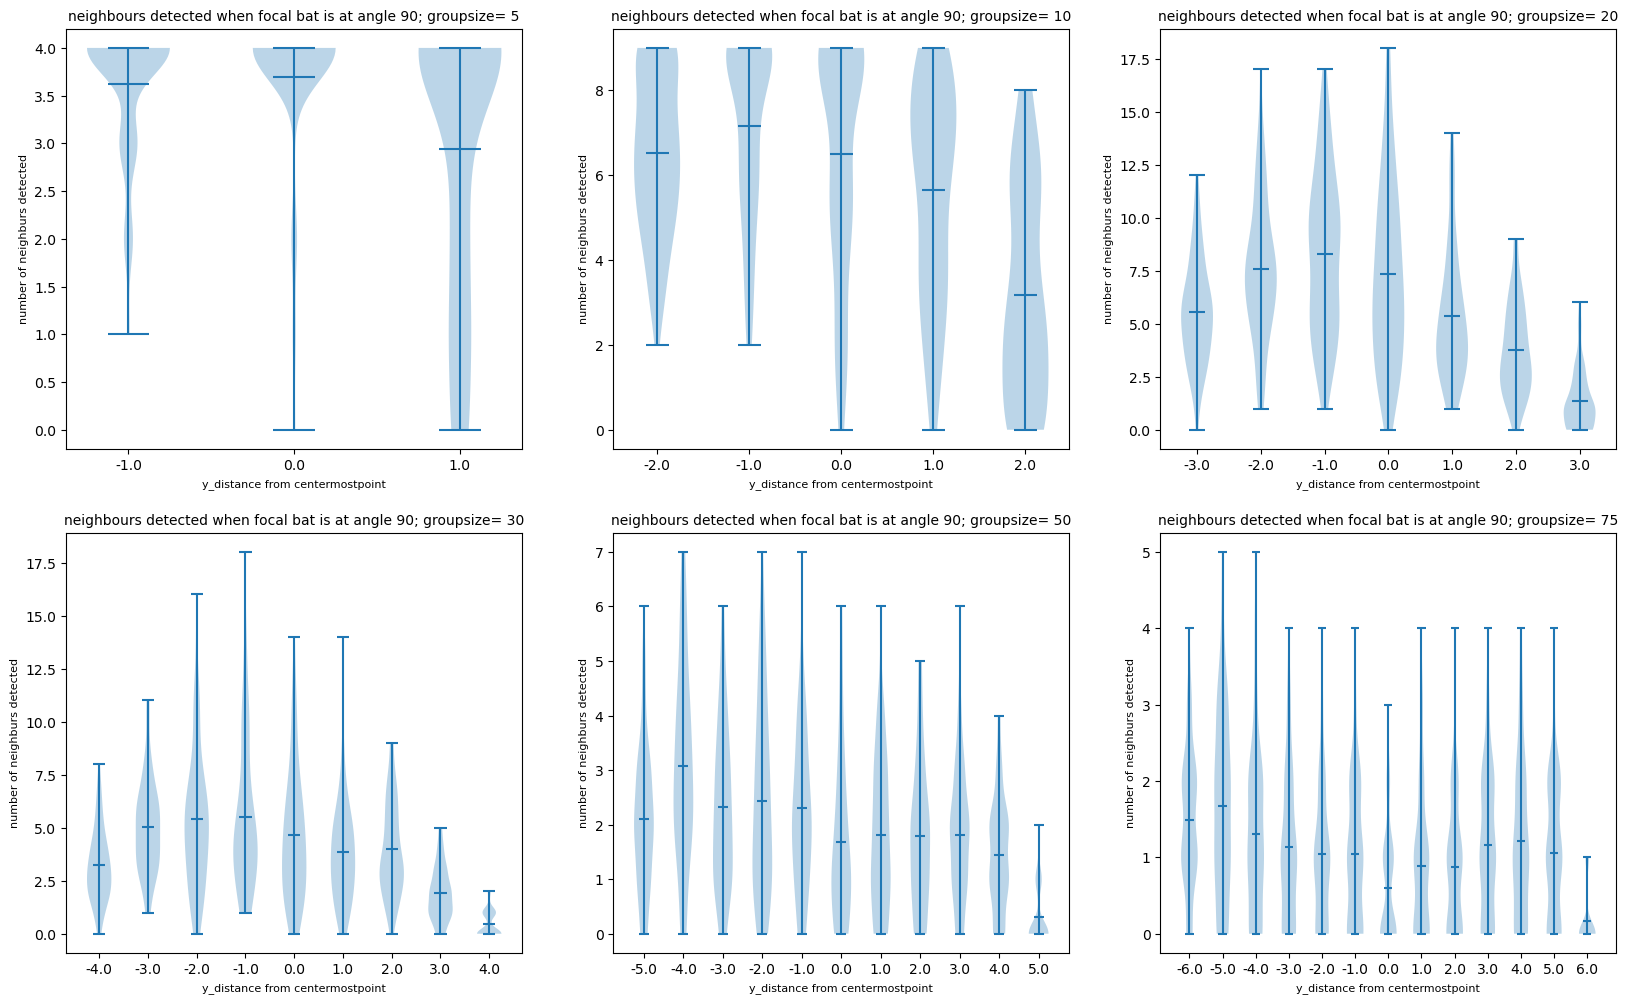

In [ ]:


# fig, axs = plt.subplots(1,1, figsize=(27,9))
i=0; 
number_of_columns=3; number_of_rows= int(np.ceil(len(group_sizes)/number_of_columns))
plt.figure(figsize=(20,12))
for group_size in group_sizes:
    nbrs_detected_data = {}
    nbrs_detected_data['num_nbrs'] = []
    nbrs_detected_data['median_num_nbrs'] = []
    nbrs_detected_data['90%ile_num_nbrs'] = []
    
    x_ticks= []; iterant_sign=-1
    for simulation_data in sublist_of_simulation_data_intransect:
        iterant_sign+=1
        try:
            dataframe = simulation_data.groupby(['group_size']).get_group(group_size)    
            if len(dataframe["nbrs_detected"])<90:
                continue
            nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
            nbrs_detected_data['median_num_nbrs'].append(np.median(np.array(dataframe['nbrs_detected'])))
            nbrs_detected_data['90%ile_num_nbrs'].append(np.percentile(np.array(dataframe['nbrs_detected']), 90))    
        except KeyError:
            continue
        x_ticks.append(sign_based_on_distance_from_centermost_point[iterant_sign]*simulation_data["focal_bat"][0][0])

        

    plt.subplot(number_of_rows,number_of_columns,i+1)
    plt.violinplot(nbrs_detected_data['num_nbrs'], showmeans=True)
    # plt.boxplot(nbrs_detected_data['num_nbrs'], showmeans=True)
    plt.title(f"neighbours detected when focal bat is at angle {90}; groupsize= {group_size}", fontsize= "10")
    plt.xticks(np.arange(1,len(x_ticks)+1),x_ticks)
    # plt.show()
    # plt.ylim(0,group_size+0.5)
    # plt.axhline(group_size-1, ls="-.", color="red", label= "group_size - 1")
    plt.xlabel("y_distance from centermostpoint", fontsize= "8")
    plt.ylabel("number of neighburs detected", fontsize= "8")
    # plt.legend(fontsize= "8")

    i+=1

The number of neighbours detected shows an increase with group size initially and then drops sharply down beyond 30 bats. 


### How does the probability of detecting at least one neighbour change with group size?

In [88]:
def calculate_geqNneighbour(num_detected_neighbours, N):
    '''Calculates the proportion of an array-like
    object that is >= N.
    
    '''
    geq_N = np.float64(np.sum(num_detected_neighbours>=N))
    if np.isnan(np.min(num_detected_neighbours)):
        return np.nan
    proportion_geq_N = geq_N/len(num_detected_neighbours)
    return(proportion_geq_N)

In [89]:
simulation_data.keys()

Index(['nbrs_detected', 'group_size', 'group_diameter',
       'nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid', 'seed',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth',
       'heading_variation', 'echocall_duration', 'atmospheric_attenuation',
       'min_spacing', 'source_level', 'interpulse_interval',
       'implement_shadowing', 'focal_bat'],
      dtype='object')

In [90]:
sublist_of_simulation_data_intransect[1]

,nbrs_detected,group_size,group_diameter,nearest_neighbour_distance,nbrs_detected_distance,uuid,seed,paramset_id,parameters_joint,echo_levels,detection_azimuth,heading_variation,echocall_duration,atmospheric_attenuation,min_spacing,source_level,interpulse_interval,implement_shadowing,focal_bat
0,3,75,6.009483,"[0.5489166825343099, 0.5511456799379195, 0.601...","[0.6235669863589259, 0.5489166825343099, 0.601...",ab2e1e2d-1bb0-4204-beee-ea8141ffada1,341979437,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[66.86509295135538, 68.79463350793657, 67.9326...","[19.351, -39.4717, 74.7336]",10,0.0025,-1,0.5,100,0.1,True,"[5.0, 4.71238898038469]"
1,2,50,5.138501,"[0.5952584043318684, 0.8013465346943426, 0.863...","[0.8637846103037564, 0.5952584043318684]",569b7faf-b923-4b25-904b-a2ac4d86b665,23324449,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[59.238760375757934, 67.38544125922148]","[-54.1771, 79.4347]",10,0.0025,-1,0.5,100,0.1,True,"[5.0, 4.71238898038469]"
2,0,75,5.748531,"[0.5045862934488272, 0.5206649229987959, 0.615...",[],5bc1f95a-d088-4122-be87-48dfb439d447,437115140,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]",[],[],10,0.0025,-1,0.5,100,0.1,True,"[5.0, 4.71238898038469]"
3,1,75,6.195440,"[0.6318326760189468, 0.6351277737223749, 0.702...",[0.6351277737223749],078db7c5-8168-4229-a3a0-563c3dc66211,1009102262,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]",[67.17658154228486],[73.4241],10,0.0025,-1,0.5,100,0.1,True,"[5.0, 4.71238898038469]"
4,3,75,5.906101,"[0.5273521438395968, 0.5670628558185895, 0.676...","[0.5670628558185895, 0.856049632167122, 0.5273...",0c33512c-43d7-4a21-971e-8cc40ad20a94,1004911916,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[68.01011652819173, 59.74764293492945, 57.3326...","[80.8453, -87.936, 138.3732]",10,0.0025,-1,0.5,100,0.1,True,"[5.0, 4.71238898038469]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2,75,6.177751,"[0.5550719964854683, 0.6125375679964818, 0.632...","[0.5550719964854683, 0.6327824039216594]",d6e8658c-cb93-4d76-854a-f0612898a5c6,429705213,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[69.98962494884103, 64.95819328200723]","[-22.144, -88.1859]",10,0.0025,-1,0.5,100,0.1,True,"[5.0, 4.71238898038469]"
196,2,75,6.164767,"[0.5699849375092659, 0.6432421828651436, 0.687...","[0.6432421828651436, 0.8019647341976734]",75678066-9a15-423f-926d-4c62a656649f,134476997,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[64.2605093431819, 60.9544829110314]","[90.8147, -87.4703]",10,0.0025,-1,0.5,100,0.1,True,"[5.0, 4.71238898038469]"
197,6,50,4.932100,"[0.5079063107061143, 0.5401803837858072, 0.624...","[1.687862073236806, 0.5079063107061143, 1.2424...",6b3ad0ae-aaa7-4b8a-99bf-9d46707b3e67,723078525,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]","[49.76293109273356, 70.88509133023989, 52.4220...","[-34.3668, -6.1872, -58.0274, 46.8546, -74.640...",10,0.0025,-1,0.5,100,0.1,True,"[5.0, 4.71238898038469]"
198,0,75,6.167087,"[0.5415778298311887, 0.6450022487949751, 0.655...",[],59f287fa-975a-4cd1-b319-84fd1113a6c7,691458074,10*0.0025*-1*0.5*100*0.1*True,"[10, 0.0025, -1, 0.5, 100, 0.1, True]",[],[],10,0.0025,-1,0.5,100,0.1,True,"[5.0, 4.71238898038469]"


In [120]:
def calculate_geqNneighbour(num_detected_neighbours, N):
    '''Calculates the proportion of an array-like
    object that is >= N.
    
    '''
    geq_N = np.float64(np.sum(num_detected_neighbours>=N))
    if np.isnan(np.min(num_detected_neighbours)):
        return np.nan
    proportion_geq_N = geq_N/len(num_detected_neighbours)
    return(proportion_geq_N)

def calculate_geqNneighbour_distribution(num_detected_neighbours, N, sub_sample_size, sub_samples_iterations, seed):
    '''Calculates the proportion of an array-like
    object that is >= N.
    
    '''
    # print(num_detected_neighbours)
    if np.isnan(np.mean(num_detected_neighbours)):
        return np.array(sub_samples_iterations*[np.nan])
    if seed!=False:
        np.random.seed(seed)
    array_containing_subsampled_probabilities=[]

    for it in range(sub_samples_iterations):
        sub_sampled_num_detected_neighbours= np.random.choice(num_detected_neighbours, size= sub_sample_size, replace=False)    
        geq_N = np.float64(np.sum(sub_sampled_num_detected_neighbours>=N))
        if np.isnan(np.min(sub_sampled_num_detected_neighbours)):
            return np.nan
        proportion_geq_N = geq_N/len(sub_sampled_num_detected_neighbours)
        array_containing_subsampled_probabilities.append(proportion_geq_N)
    return np.array(array_containing_subsampled_probabilities)

In [134]:
#store data
store_probability_of_detection_n_neighbour= {}
group_sizes= [5,10,20,30,50,75]
i=0
for simulation_data in sublist_of_simulation_data_intransect:
        data_by_groupsize = simulation_data.groupby(['group_size'])

        nbrs_detected_data = {}
        nbrs_detected_data["group_sizes"]= group_sizes
        nbrs_detected_data['num_nbrs'] = []
        nbrs_detected_data['median_num_nbrs'] = []
        nbrs_detected_data['90%ile_num_nbrs'] = []
        groupsizes= []

        for groupsize, dataframe in data_by_groupsize:
                if len(dataframe)<95:
                        print(len(dataframe))
                        continue
                groupsizes.append(groupsize[0])
                nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
                nbrs_detected_data['median_num_nbrs'].append(np.median(np.array(dataframe['nbrs_detected'])))
                nbrs_detected_data['90%ile_num_nbrs'].append(np.percentile(np.array(dataframe['nbrs_detected']), 90))
        nan_groupsizes= [i for i in group_sizes if i not in groupsizes]

        for nan_groupsize in nan_groupsizes:
                nbrs_detected_data['num_nbrs']= [np.nan, *nbrs_detected_data['num_nbrs']]
                nbrs_detected_data['median_num_nbrs']= [np.nan, *nbrs_detected_data['median_num_nbrs']]
                nbrs_detected_data['90%ile_num_nbrs']= [np.nan, *nbrs_detected_data['90%ile_num_nbrs']]

        nbrs_detected_data['0neighbours'] = [ 1-calculate_geqNneighbour(each,1)  for each in nbrs_detected_data['num_nbrs']]
        nbrs_detected_data['geq_1neighbour'] = [ calculate_geqNneighbour(each,1)  for each in nbrs_detected_data['num_nbrs']]
        nbrs_detected_data['geq_2neighbour'] = [ calculate_geqNneighbour(each,2)  for each in nbrs_detected_data['num_nbrs']]
        nbrs_detected_data['geq_3neighbour'] = [ calculate_geqNneighbour(each,3)  for each in nbrs_detected_data['num_nbrs']]
        nbrs_detected_data['geq_4neighbour'] = [ calculate_geqNneighbour(each,4)  for each in nbrs_detected_data['num_nbrs']]

        # print(nbrs_detected_data['num_nbrs'])
        nbrs_detected_data['0neighbours_dist'] = [ 1-calculate_geqNneighbour_distribution(each,1, 50, 100, False)  for each in nbrs_detected_data['num_nbrs']]
        nbrs_detected_data['geq_1neighbour_dist'] = [ calculate_geqNneighbour_distribution(each,1, 50, 100, False)  for each in nbrs_detected_data['num_nbrs']]
        nbrs_detected_data['geq_2neighbour_dist'] = [ calculate_geqNneighbour_distribution(each,2, 50, 100, False)  for each in nbrs_detected_data['num_nbrs']]
        nbrs_detected_data['geq_3neighbour_dist'] = [ calculate_geqNneighbour_distribution(each,3, 50, 100, False)  for each in nbrs_detected_data['num_nbrs']]
        nbrs_detected_data['geq_4neighbour_dist'] = [ calculate_geqNneighbour_distribution(each,4, 50, 100, False)  for each in nbrs_detected_data['num_nbrs']]

        nbrs_detected_data['detected_distances'] = [ np.concatenate(np.array(dataframe['nbrs_detected_distance'])) for groupsize, dataframe in data_by_groupsize]
        nbrs_detected_data['median_detected_distances'] = map(np.median, nbrs_detected_data['detected_distances'])
        nbrs_detected_data['90%ile_detected_distances'] = map(lambda X : np.percentile(X,90),
                                                        nbrs_detected_data['detected_distances'][:-1])

        nbrs_detected_data['neighbours_azimuth'] = [ np.concatenate(np.array(dataframe['detection_azimuth'])) for groupsize, dataframe in data_by_groupsize]
        nbrs_detected_data['median_neighbours_azimuth'] = [ np.median(each)  for each in nbrs_detected_data['neighbours_azimuth'] ]
        nbrs_detected_data['95%ile_neighbours_azimuth'] = [ np.percentile(each, 92.5)  for each in nbrs_detected_data['neighbours_azimuth'][:-1] ]
        nbrs_detected_data['5%ile_neighbours_azimuth'] = [ np.percentile(each, 2.5)  for each in nbrs_detected_data['neighbours_azimuth'][:-1] ]

        nbrs_detected_data['echolevels'] = [ np.concatenate(np.array(dataframe['echo_levels'])) for groupsize, dataframe in data_by_groupsize]
        nbrs_detected_data['median_echolevels'] = [ np.median(each) for each in nbrs_detected_data['echolevels']]
        nbrs_detected_data['5%ile_echolevels'] = [ np.percentile(each, 2.5) for each in nbrs_detected_data['echolevels'][:-1]]
        nbrs_detected_data['95%ile_echolevels'] = [ np.percentile(each, 97.5) for each in nbrs_detected_data['echolevels'][:-1]]

        for nan_groupsize in nan_groupsizes:
                nbrs_detected_data['detected_distances']= [np.nan, *nbrs_detected_data['detected_distances']]
                nbrs_detected_data['median_detected_distances']= [np.nan, *nbrs_detected_data['median_detected_distances']]
                nbrs_detected_data['90%ile_detected_distances']= [np.nan, *nbrs_detected_data['90%ile_detected_distances']]

                nbrs_detected_data['neighbours_azimuth']= [[np.nan], *nbrs_detected_data['neighbours_azimuth']]
                nbrs_detected_data['median_neighbours_azimuth']= [np.nan, *nbrs_detected_data['median_neighbours_azimuth']]
                nbrs_detected_data['5%ile_neighbours_azimuth']= [np.nan, *nbrs_detected_data['5%ile_neighbours_azimuth']]
                nbrs_detected_data['95%ile_neighbours_azimuth']= [np.nan, *nbrs_detected_data['95%ile_neighbours_azimuth']]

                nbrs_detected_data['echolevels']= [[np.nan], *nbrs_detected_data['echolevels']]
                nbrs_detected_data['median_echolevels']= [np.nan, *nbrs_detected_data['median_echolevels']]
                nbrs_detected_data['5%ile_echolevels']= [np.nan, *nbrs_detected_data['5%ile_echolevels']]
                nbrs_detected_data['95%ile_echolevels']= [np.nan, *nbrs_detected_data['95%ile_echolevels']]
                
        
        store_probability_of_detection_n_neighbour[simulation_data["focal_bat"][0][0]*sign_based_on_distance_from_centermost_point[i]]= nbrs_detected_data
        i+=1

1


In [ ]:
nan_groupsize

50

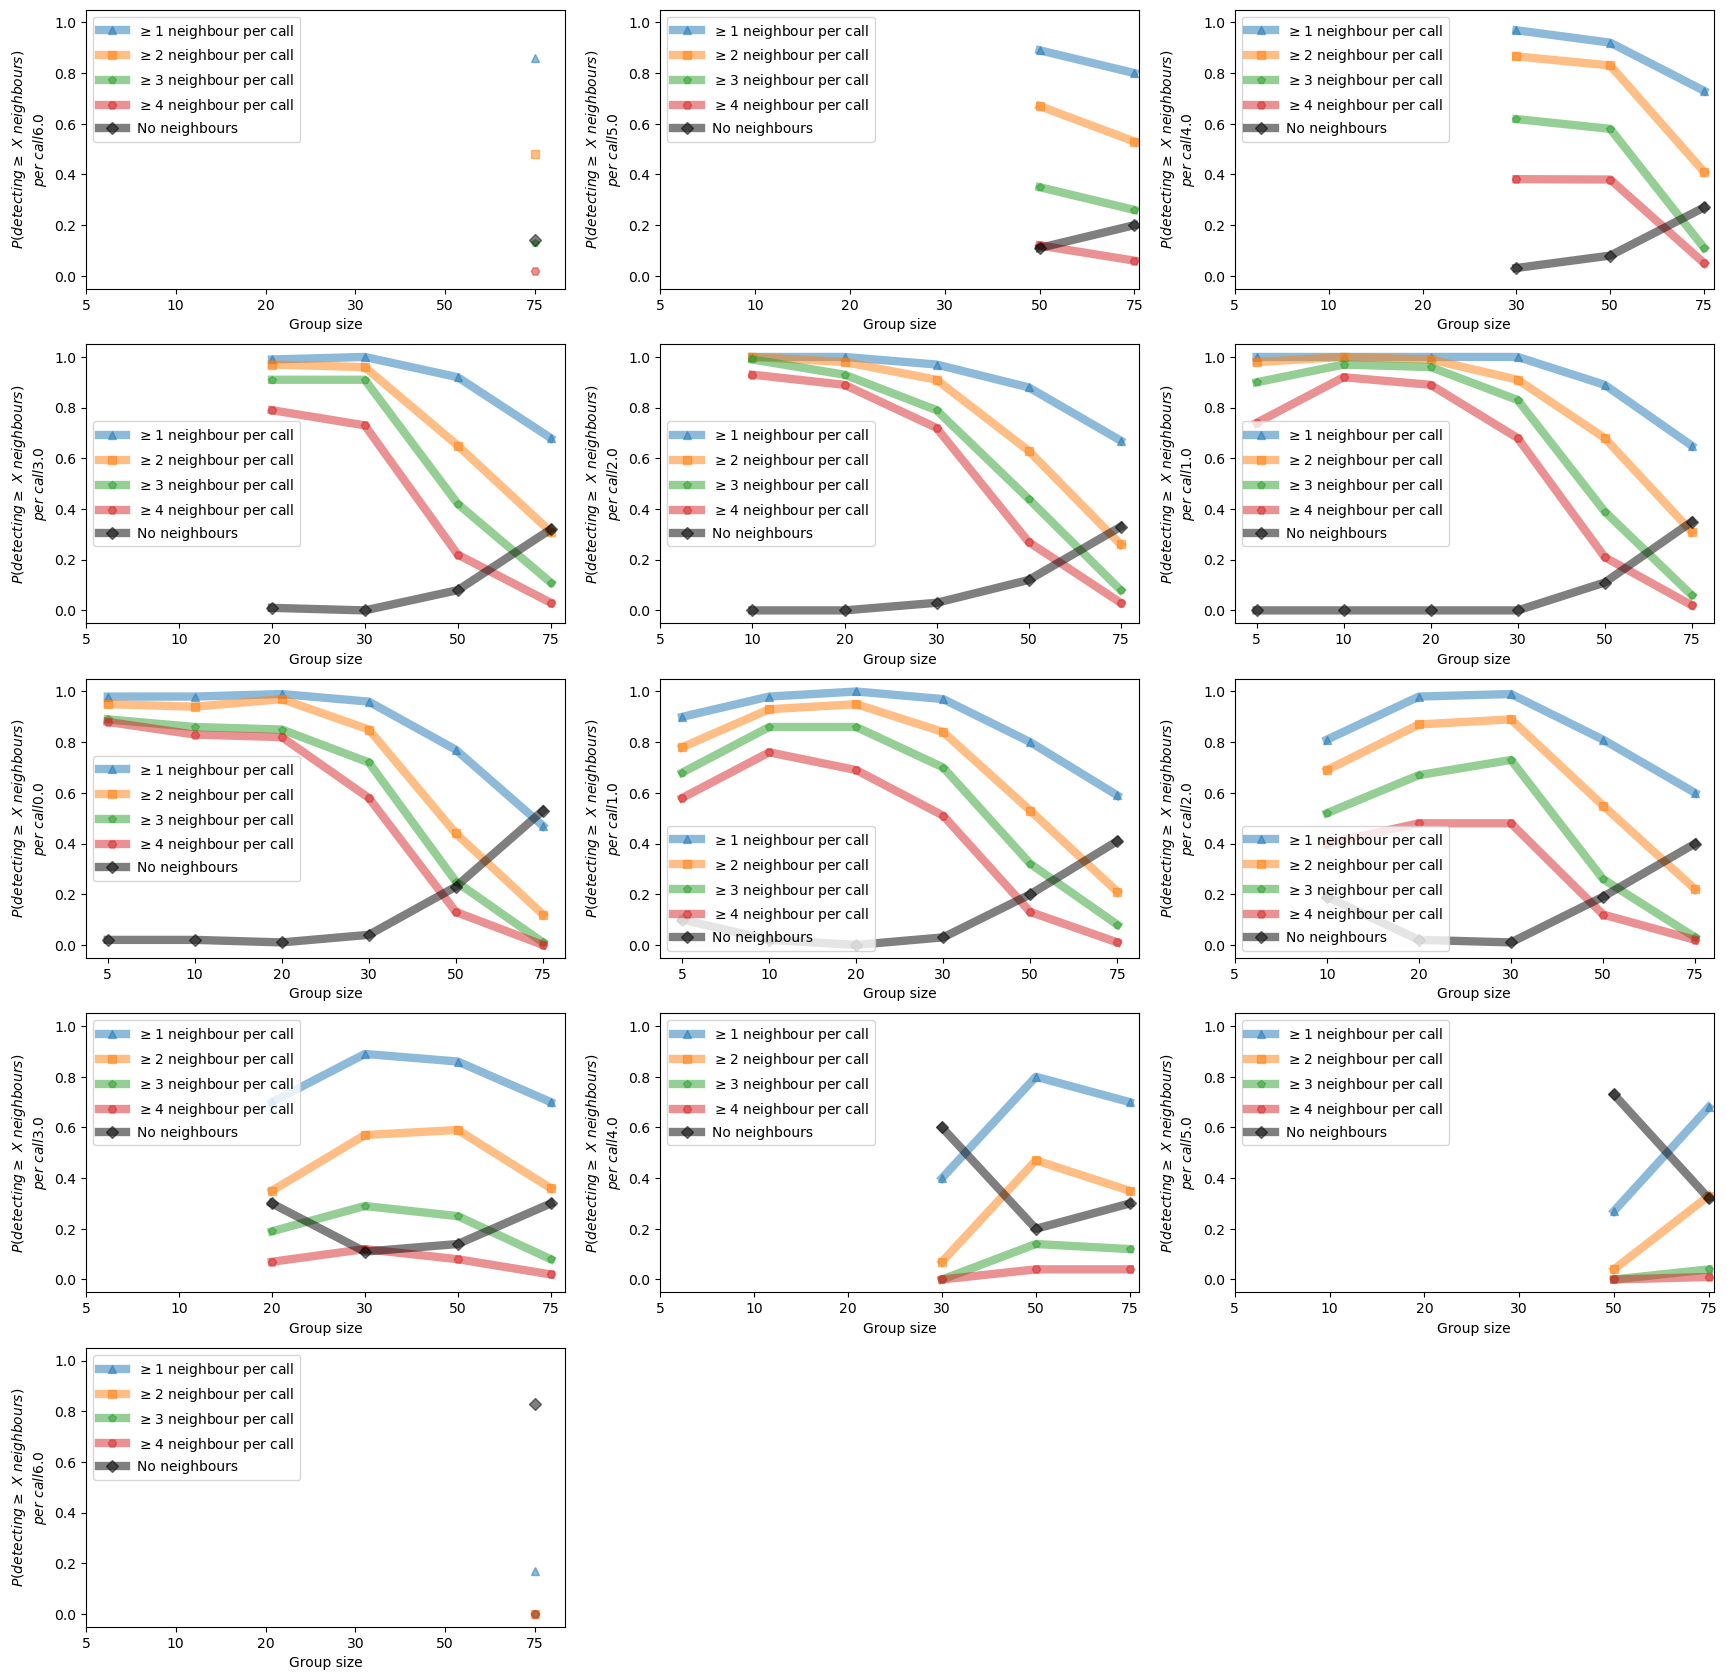

In [135]:
i=0; 
number_of_columns=3; number_of_rows= int(np.ceil(len(sublist_of_simulation_data_intransect)/number_of_columns))
plt.figure(figsize= (21,21))
for simulation_data in sublist_of_simulation_data_intransect:
        data_by_groupsize = simulation_data.groupby(['group_size'])
        groupsizes= group_sizes

        key_for_dict= simulation_data["focal_bat"][0][0]*sign_based_on_distance_from_centermost_point[i]
        nbrs_detected_data= store_probability_of_detection_n_neighbour[key_for_dict]

        plt.subplot(number_of_rows,number_of_columns,i+1)
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_1neighbour'], '-^', linewidth=6, alpha=0.5, label='$\geq1$ neighbour per call')
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_2neighbour'], '-s', linewidth=6, alpha=0.5, label='$\geq2$ neighbour per call')
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_3neighbour'], '-p', linewidth=6, alpha=0.5, label='$\geq3$ neighbour per call')
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_4neighbour'], '-H', linewidth=6, alpha=0.5, label='$\geq4$ neighbour per call')
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['0neighbours'], '-Dk', linewidth=6, alpha=0.5, label='No neighbours')

        plt.yticks(fontsize=10)
        plt.xticks(np.arange(1,len(groupsizes)+1),
                groupsizes,fontsize=10)
        plt.legend()
        plt.ylabel('$P(detecting \geq \ X \ neighbours)$'+'\n'+ '$per \ call$'+str(simulation_data["focal_bat"][0][0]),
                fontsize=10)
        plt.xlabel('Group size',
                fontsize=10)
        plt.ylim(-0.05,1.05)
        
        i+=1

In [ ]:
nbrs_detected_data['geq_1neighbour']

[nan, nan, nan, nan, nan, np.float64(0.47)]

In [152]:
import matplotlib

cmap = matplotlib.cm.get_cmap('vanimo')
colors= np.arange(0, 1, (1-0)/7)
colors= [cmap(i) for i in colors]

/tmp/ipykernel_916215/4120524370.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('vanimo')


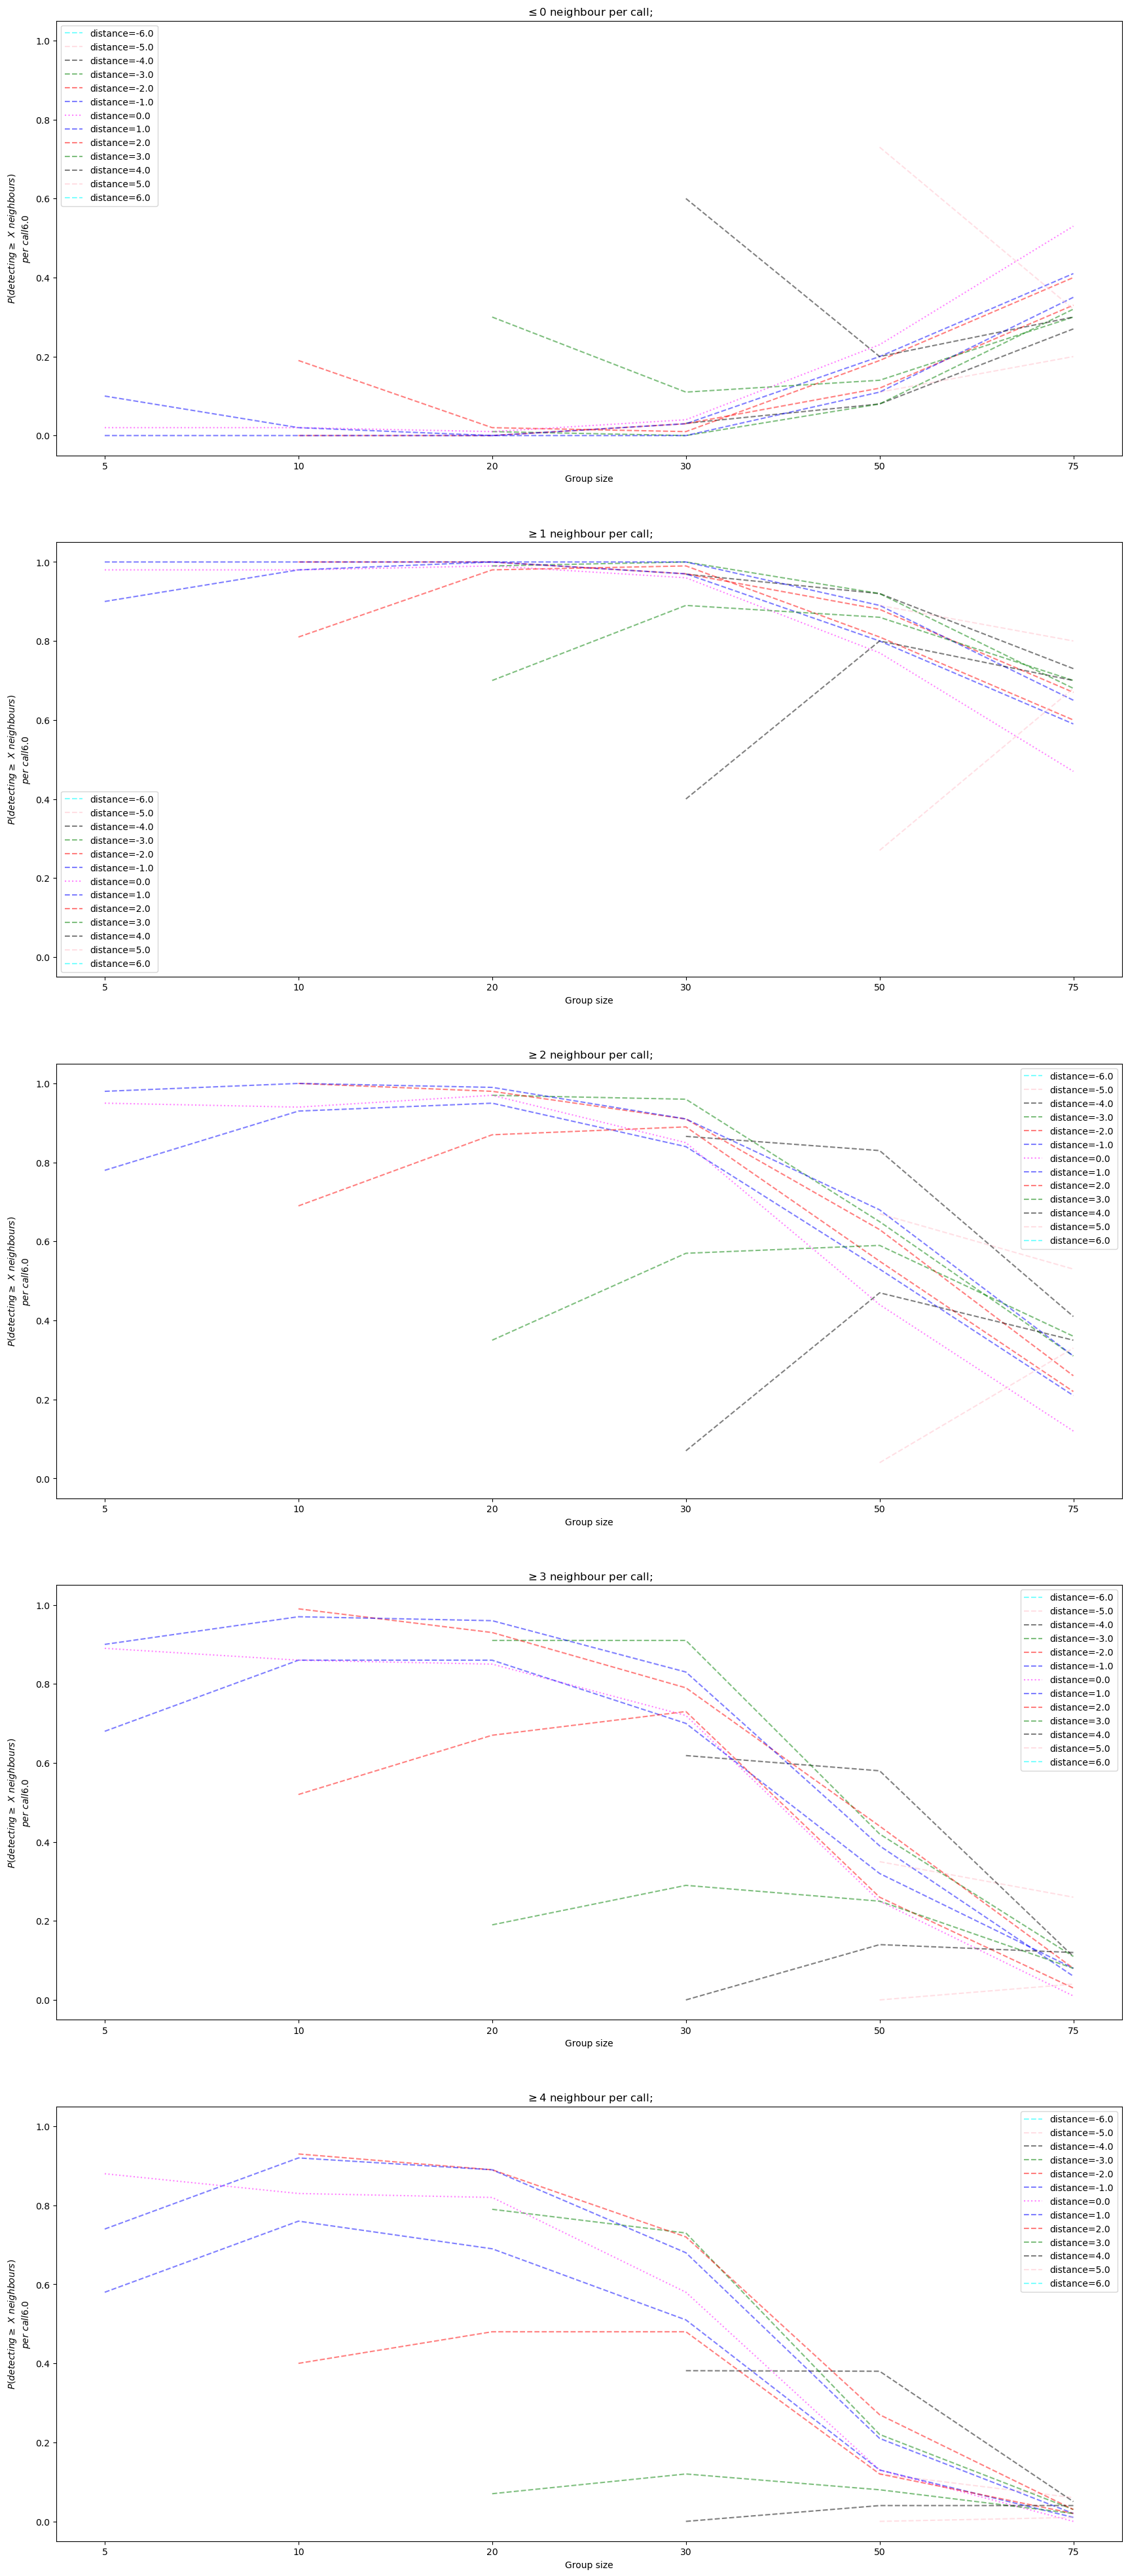

In [158]:
colors=["blue", "red", "green", "black", "pink", "cyan", "magenta"]
number_of_neighbours_atleast_detected= [0,1,2,3,4]
i=0; 
number_of_columns=1; number_of_rows= int(np.ceil(len(number_of_neighbours_atleast_detected)/number_of_columns))
plt.figure(figsize= (21,50))

for simulation_data in sublist_of_simulation_data_intransect:

        groupsizes= group_sizes

        key_for_dict= simulation_data["focal_bat"][0][0]*sign_based_on_distance_from_centermost_point[i]
        nbrs_detected_data= store_probability_of_detection_n_neighbour[key_for_dict]

        if sign_based_on_distance_from_centermost_point[i]<0:
                ls= ".-"
        if sign_based_on_distance_from_centermost_point[i]==0:
                ls= ":"
        else:
                ls= "--"

        plt.subplot(number_of_rows,number_of_columns,2)
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_1neighbour'], ls, alpha=0.5, label=f'distance={key_for_dict}', color=colors[int(simulation_data["focal_bat"][0][0]-1)])
        
        plt.subplot(number_of_rows,number_of_columns,3)
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_2neighbour'], ls, alpha=0.5, label=f'distance={key_for_dict}', color=colors[int(simulation_data["focal_bat"][0][0]-1)])
        
        plt.subplot(number_of_rows,number_of_columns,4)
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_3neighbour'], ls, alpha=0.5, label=f'distance={key_for_dict}', color=colors[int(simulation_data["focal_bat"][0][0]-1)])
        
        plt.subplot(number_of_rows,number_of_columns,5)
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_4neighbour'], ls, alpha=0.5, label=f'distance={key_for_dict}', color=colors[int(simulation_data["focal_bat"][0][0]-1)])
        
        plt.subplot(number_of_rows,number_of_columns,1)
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['0neighbours'], ls, alpha=0.5, label=f'distance={key_for_dict}', color=colors[int(simulation_data["focal_bat"][0][0]-1)])
        i+=1
for i in range(1,6):
        if i==1:
                plt.subplot(number_of_rows,number_of_columns,i)
                plt.yticks(fontsize=10)
                plt.xticks(np.arange(1,len(groupsizes)+1),
                        groupsizes,fontsize=10)
                plt.legend()
                plt.title(f"$\leq{i-1}$ neighbour per call;")
        else: 
                plt.subplot(number_of_rows,number_of_columns,i)
                plt.yticks(fontsize=10)
                plt.xticks(np.arange(1,len(groupsizes)+1),
                        groupsizes,fontsize=10)
                plt.legend()
                plt.title(f"$\geq{i-1}$ neighbour per call;")
        plt.ylabel('$P(detecting \geq \ X \ neighbours)$'+'\n'+ '$per \ call$'+str(simulation_data["focal_bat"][0][0]),
                fontsize=10)
        plt.xlabel('Group size',
                fontsize=10)
        plt.ylim(-0.05,1.05)


In [107]:
(nbrs_detected_data['geq_1neighbour_dist'])

[array([nan]),
 array([nan]),
 array([nan]),
 array([nan]),
 array([nan]),
 array([0.84, 0.86, 0.86, 0.9 , 0.88, 0.88, 0.9 , 0.92, 0.86, 0.88, 0.92,
        0.86, 0.84, 0.86, 0.86, 0.88, 0.88, 0.86, 0.9 , 0.88, 0.84, 0.86,
        0.88, 0.88, 0.86, 0.76, 0.82, 0.82, 0.9 , 0.88, 0.9 , 0.82, 0.82,
        0.84, 0.86, 0.9 , 0.86, 0.88, 0.86, 0.82, 0.92, 0.84, 0.86, 0.88,
        0.82, 0.84, 0.86, 0.86, 0.82, 0.9 , 0.86, 0.82, 0.84, 0.8 , 0.88,
        0.82, 0.88, 0.9 , 0.82, 0.86, 0.82, 0.88, 0.82, 0.88, 0.84, 0.88,
        0.84, 0.86, 0.88, 0.86, 0.84, 0.86, 0.86, 0.9 , 0.84, 0.8 , 0.88,
        0.92, 0.88, 0.84, 0.88, 0.84, 0.82, 0.86, 0.86, 0.86, 0.92, 0.8 ,
        0.84, 0.86, 0.94, 0.88, 0.9 , 0.86, 0.82, 0.82, 0.86, 0.84, 0.82,
        0.84])]

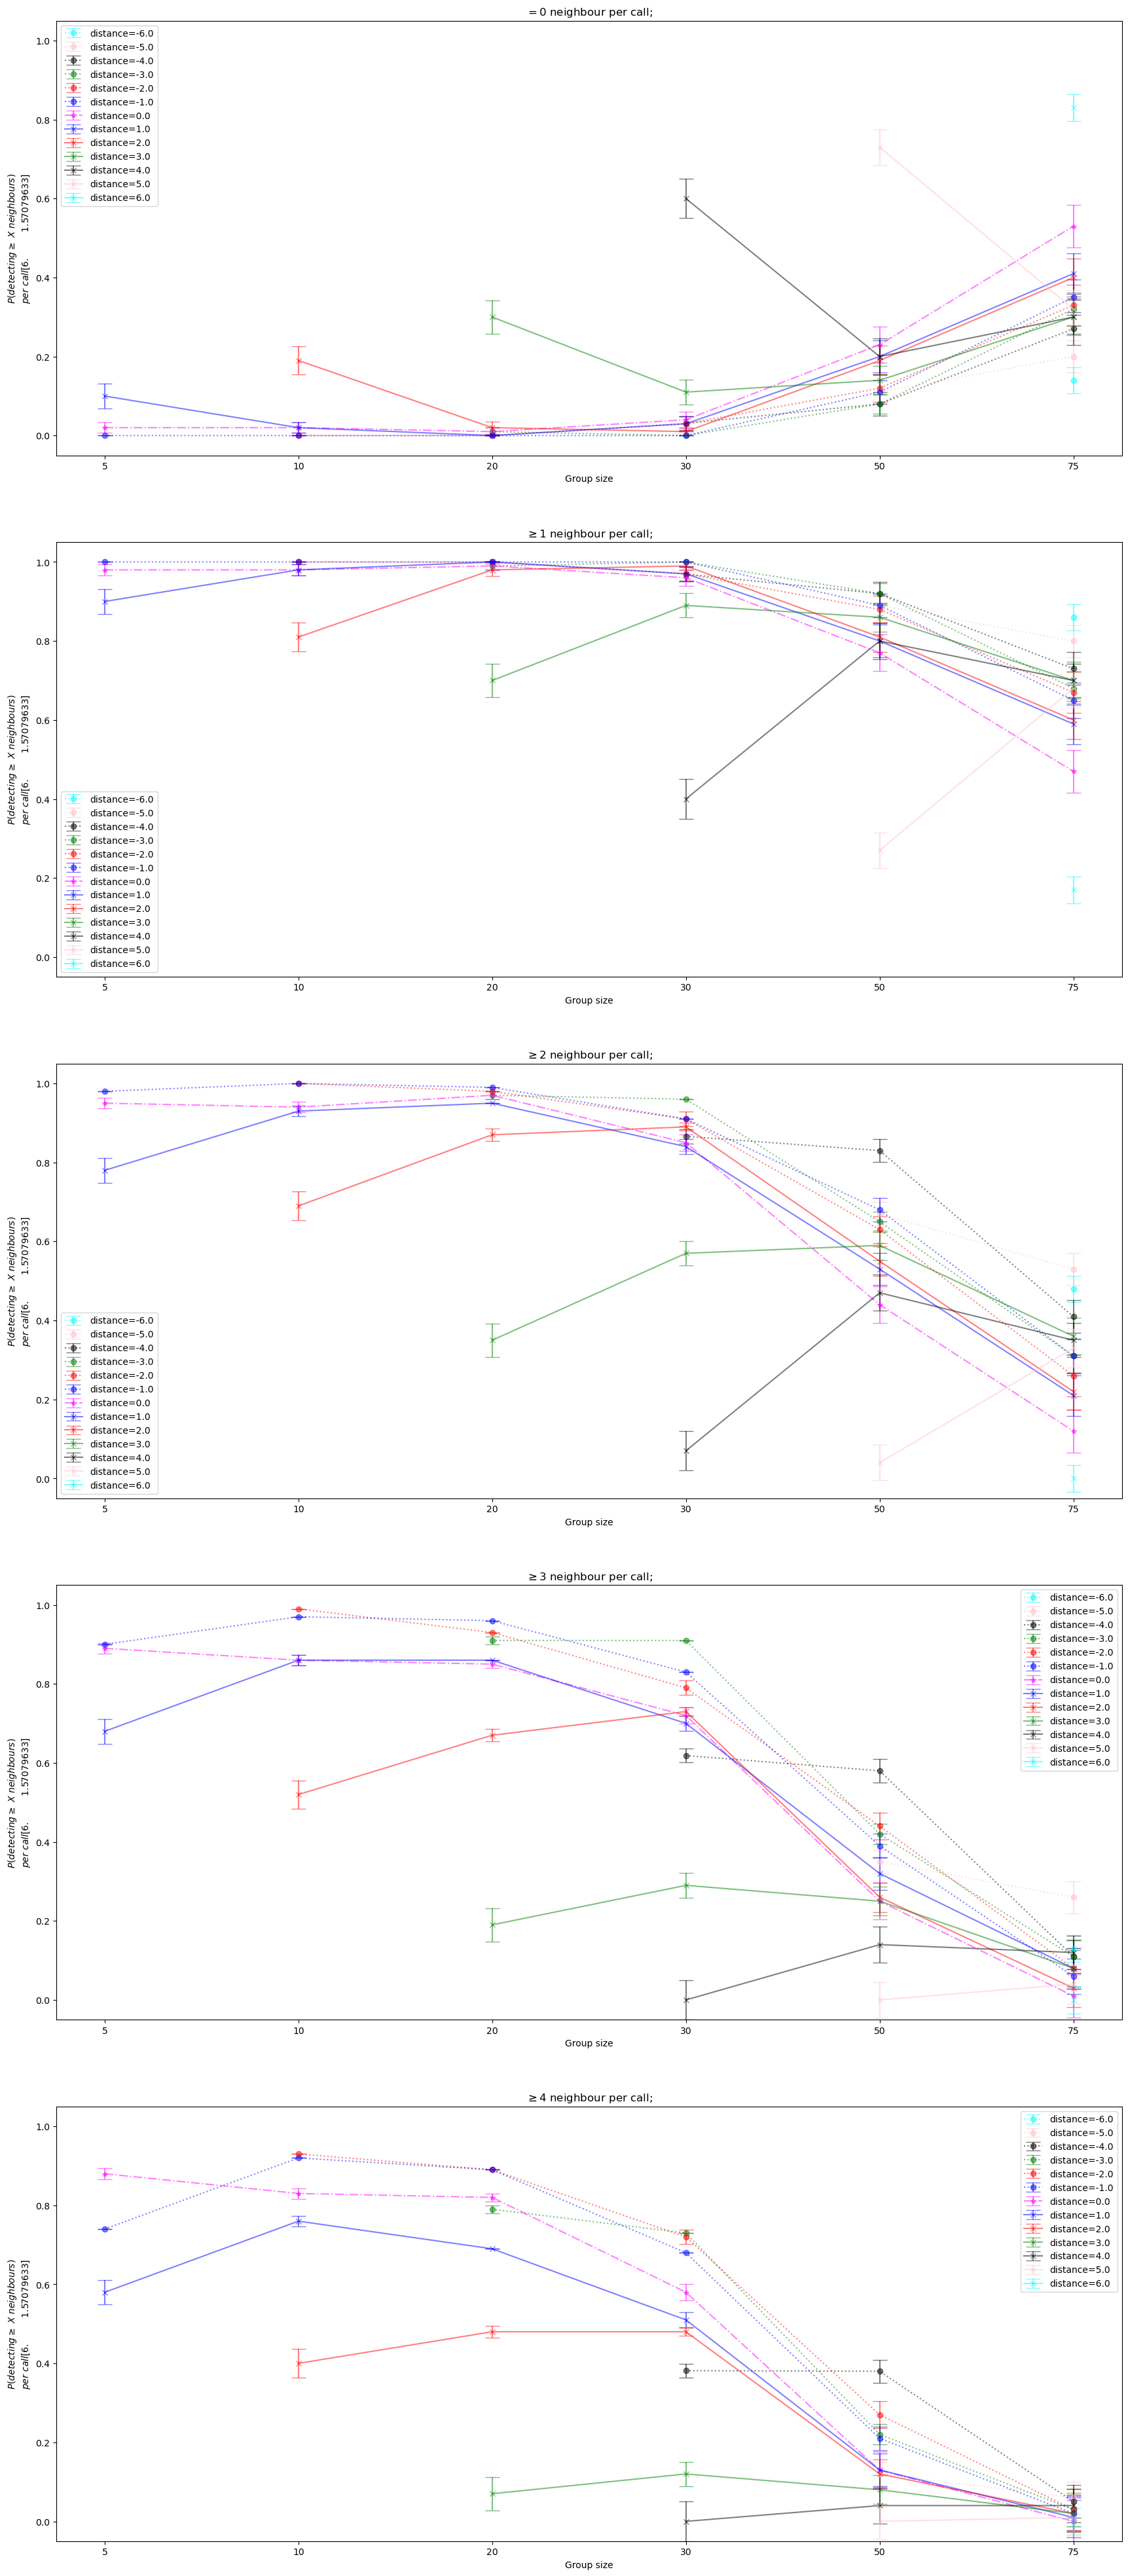

In [ ]:
i=0;  
number_of_neighbours_atleast_detected=[0,1,2,3,4]
number_of_columns=1; number_of_rows= int(np.ceil(len(number_of_neighbours_atleast_detected)/number_of_columns))
plt.figure(figsize= (21,50))

for simulation_data in sublist_of_simulation_data_intransect:
        color_given_index= colors[int(float(simulation_data["focal_bat"][0][0]))-1]
        groupsizes= group_sizes

        key_for_dict= simulation_data["focal_bat"][0][0]*sign_based_on_distance_from_centermost_point[i]
        nbrs_detected_data= store_probability_of_detection_n_neighbour[key_for_dict]

        if sign_based_on_distance_from_centermost_point[i]<0:
                ls= ":"
                fmt="o"
        elif sign_based_on_distance_from_centermost_point[i]==0:
                ls= "-."
                fmt= "*"
        else:
                ls= "-"
                fmt="x"

        # key_for_dict= simulation_data["heading_var"][0]
        nbrs_detected_data= store_probability_of_detection_n_neighbour[key_for_dict]

        plt.subplot(number_of_rows,number_of_columns,2)
        plt.errorbar(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_1neighbour'], yerr=np.std(nbrs_detected_data['geq_1neighbour_dist'], axis=1),ls=ls, alpha=0.5, label=f'distance={key_for_dict}', capsize= 8.0, fmt=fmt, color=color_given_index)
        
        plt.subplot(number_of_rows,number_of_columns,3)
        plt.errorbar(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_2neighbour'], yerr=np.std(nbrs_detected_data['geq_1neighbour_dist'], axis=1),ls=ls, alpha=0.5, label=f'distance={key_for_dict}', capsize= 8.0, fmt=fmt, color=color_given_index)
        
        plt.subplot(number_of_rows,number_of_columns,4)
        plt.errorbar(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_3neighbour'], yerr=np.std(nbrs_detected_data['geq_1neighbour_dist'], axis=1),ls=ls, alpha=0.5, label=f'distance={key_for_dict}', capsize= 8.0, fmt=fmt, color=color_given_index)
        
        plt.subplot(number_of_rows,number_of_columns,5)
        plt.errorbar(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_4neighbour'], yerr=np.std(nbrs_detected_data['geq_1neighbour_dist'], axis=1),ls=ls, alpha=0.5, label=f'distance={key_for_dict}', capsize= 8.0, fmt=fmt, color=color_given_index)
        
        plt.subplot(number_of_rows,number_of_columns,1)
        plt.errorbar(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['0neighbours'], yerr=np.std(nbrs_detected_data['geq_1neighbour_dist'], axis=1),ls=ls, alpha=0.5, label=f'distance={key_for_dict}', capsize= 8.0, fmt=fmt, color=color_given_index)
        i+=1
for i in range(1,6):
        if i==1:
                plt.subplot(number_of_rows,number_of_columns,i)
                plt.yticks(fontsize=10)
                plt.xticks(np.arange(1,len(groupsizes)+1),
                        groupsizes,fontsize=10)
                plt.legend()
                plt.title(f"$={i-1}$ neighbour per call;")
        else: 
                plt.subplot(number_of_rows,number_of_columns,i)
                plt.yticks(fontsize=10)
                plt.xticks(np.arange(1,len(groupsizes)+1),
                        groupsizes,fontsize=10)
                plt.legend()
                plt.title(f"$\geq{i-1}$ neighbour per call;")
        plt.ylabel('$P(detecting \geq \ X \ neighbours)$'+'\n'+ '$per \ call$'+str(simulation_data["focal_bat"][0]),
                fontsize=10)
        plt.xlabel('Group size',
                fontsize=10)
        plt.ylim(-0.05,1.05)

-6.0
-5.0
-4.0
-3.0
-2.0
-1.0
1.0
2.0
3.0
4.0
5.0
6.0


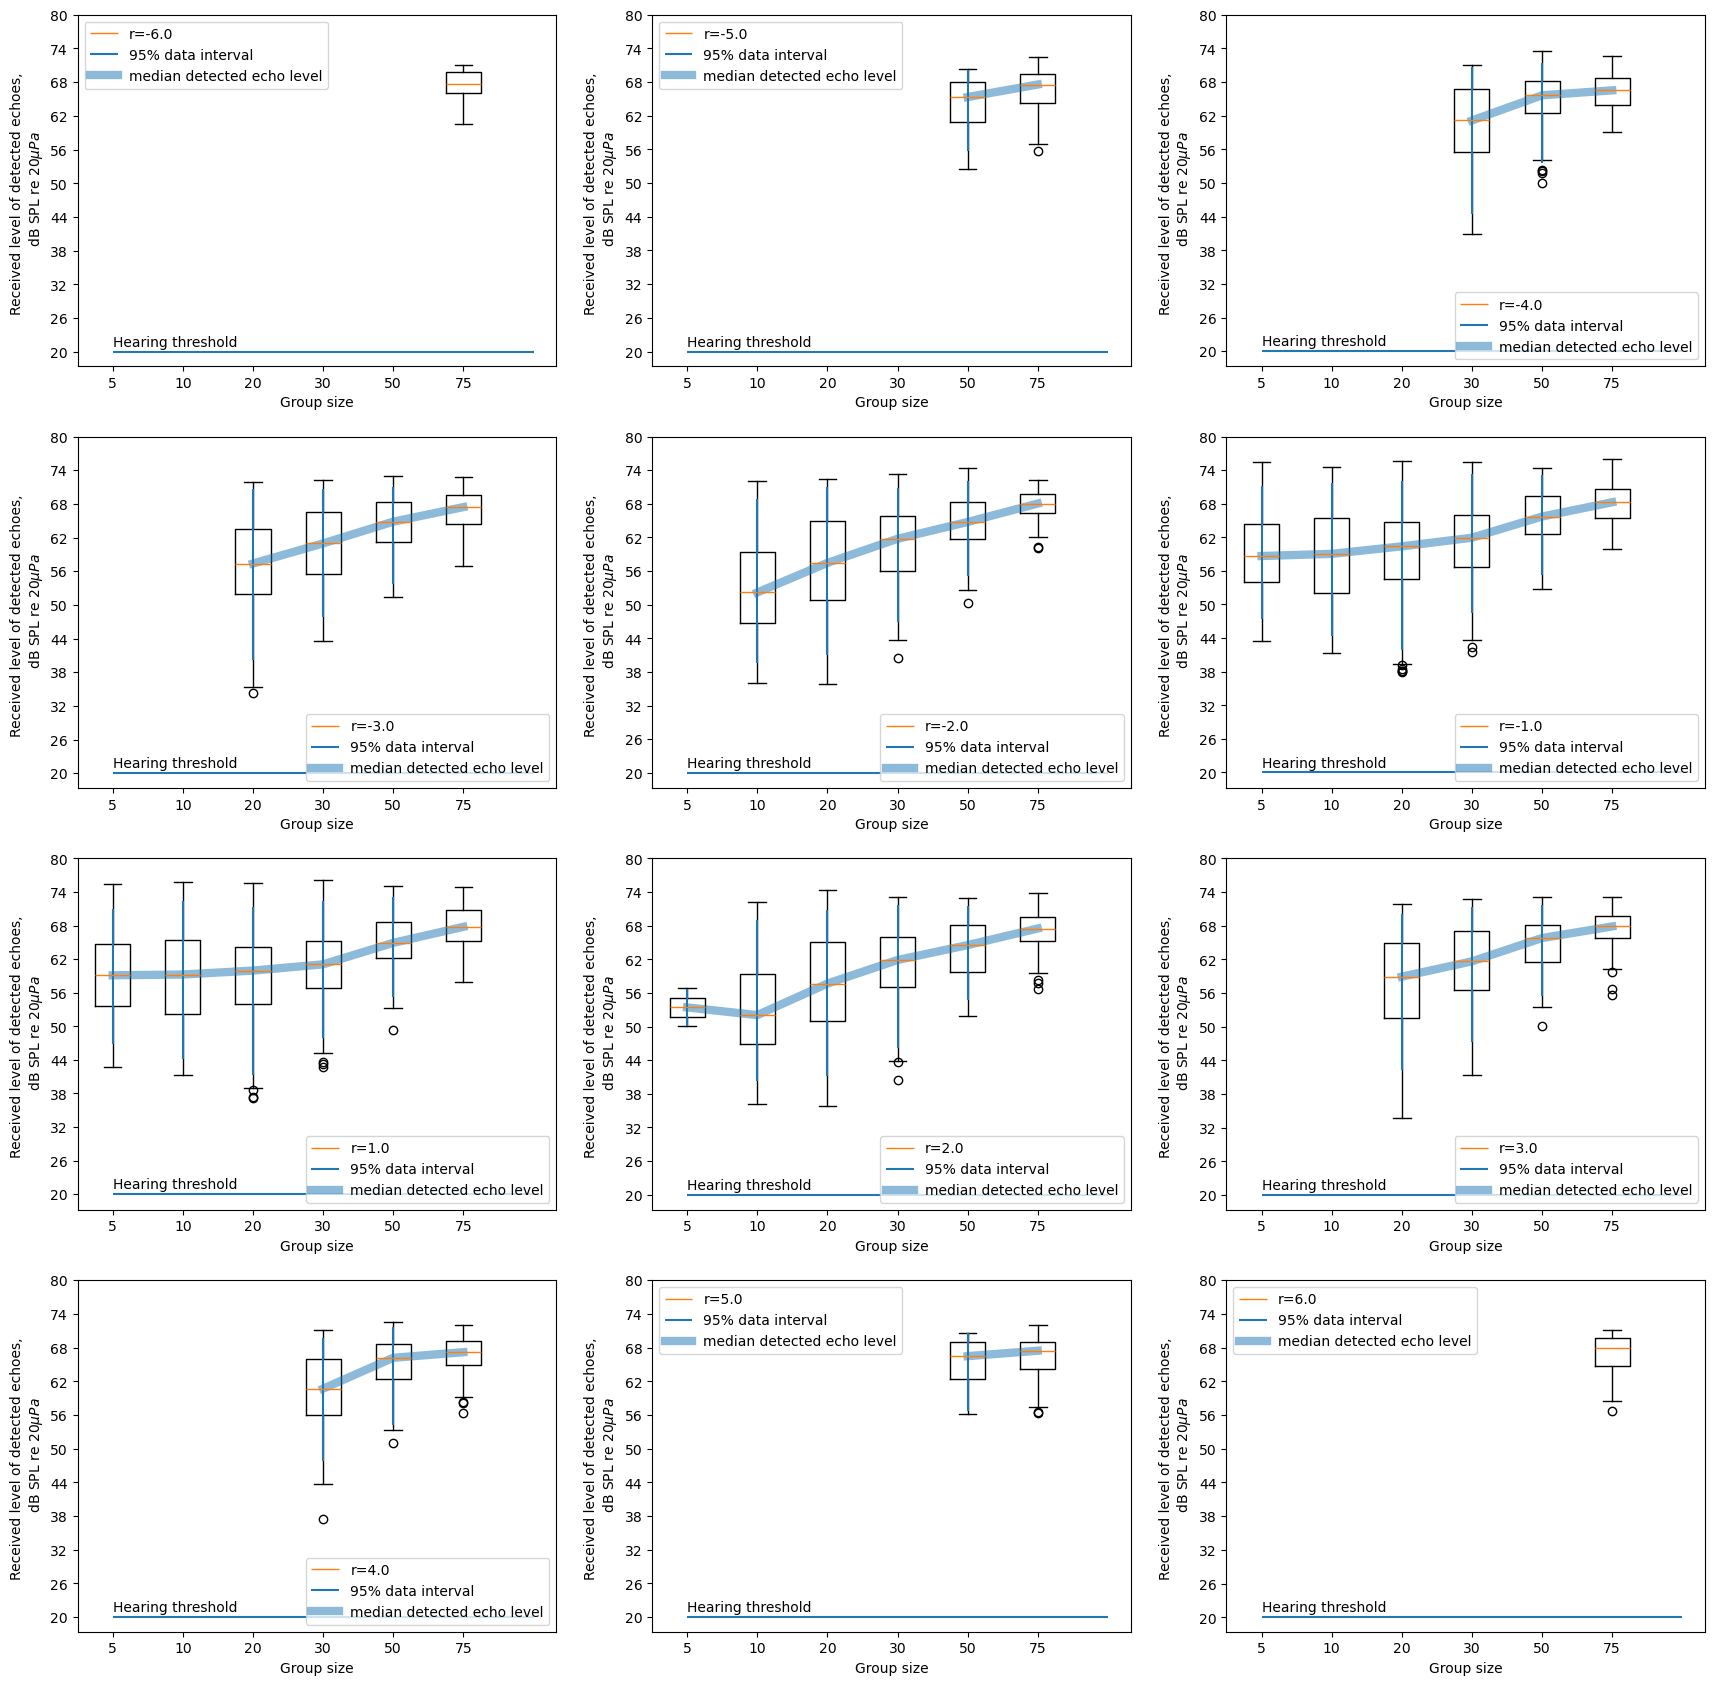

In [ ]:

i=0; 
number_of_columns=3; number_of_rows= int(np.ceil(len(sublist_of_simulation_data_intransect)/number_of_columns))
plt.figure(figsize= (21,21))
for simulation_data in sublist_of_simulation_data_intransect:
        groupsizes= group_sizes
        key_for_dict= simulation_data["focal_bat"][0][0]*sign_based_on_distance_from_centermost_point[i]
        nbrs_detected_data= store_probability_of_detection_n_neighbour[key_for_dict]

        plt.subplot(number_of_rows,number_of_columns,i+1)
        plt.boxplot(nbrs_detected_data['echolevels'][:], label=f"r={key_for_dict}");
        plt.vlines(range(1,len(nbrs_detected_data['95%ile_echolevels'])+1),nbrs_detected_data['5%ile_echolevels'],
                                                                        nbrs_detected_data['95%ile_echolevels'],
                                label='95% data interval')

        plt.plot(range(1,len(groupsizes)+1), nbrs_detected_data['median_echolevels'], linewidth=6, alpha=0.5,
                label='median detected echo level')
        plt.ylabel('Received level of detected echoes, \n dB SPL re 20$\mu Pa$',
                                                fontsize=10)
        plt.xticks(np.arange(1,len(groupsizes)+1), groupsizes, fontsize=10)
        plt.hlines([20],1,len(groupsizes)+1)
        plt.yticks(np.arange(20,86,6),np.arange(20,86,6), fontsize=10)
        plt.text(1,21,'Hearing threshold', fontsize=10)
        plt.xlabel('Group size', fontsize=10)
        plt.legend()
        print(key_for_dict)
        i+=1

/tmp/ipykernel_99366/727066968.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_99366/727066968.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_99366/727066968.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_99366/727066968.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_99366/727066968.py:25: UserWarning: No artists with labels found to put in legend.  Note that

6.0
6.0
6.0
6.0
6.0
6.0


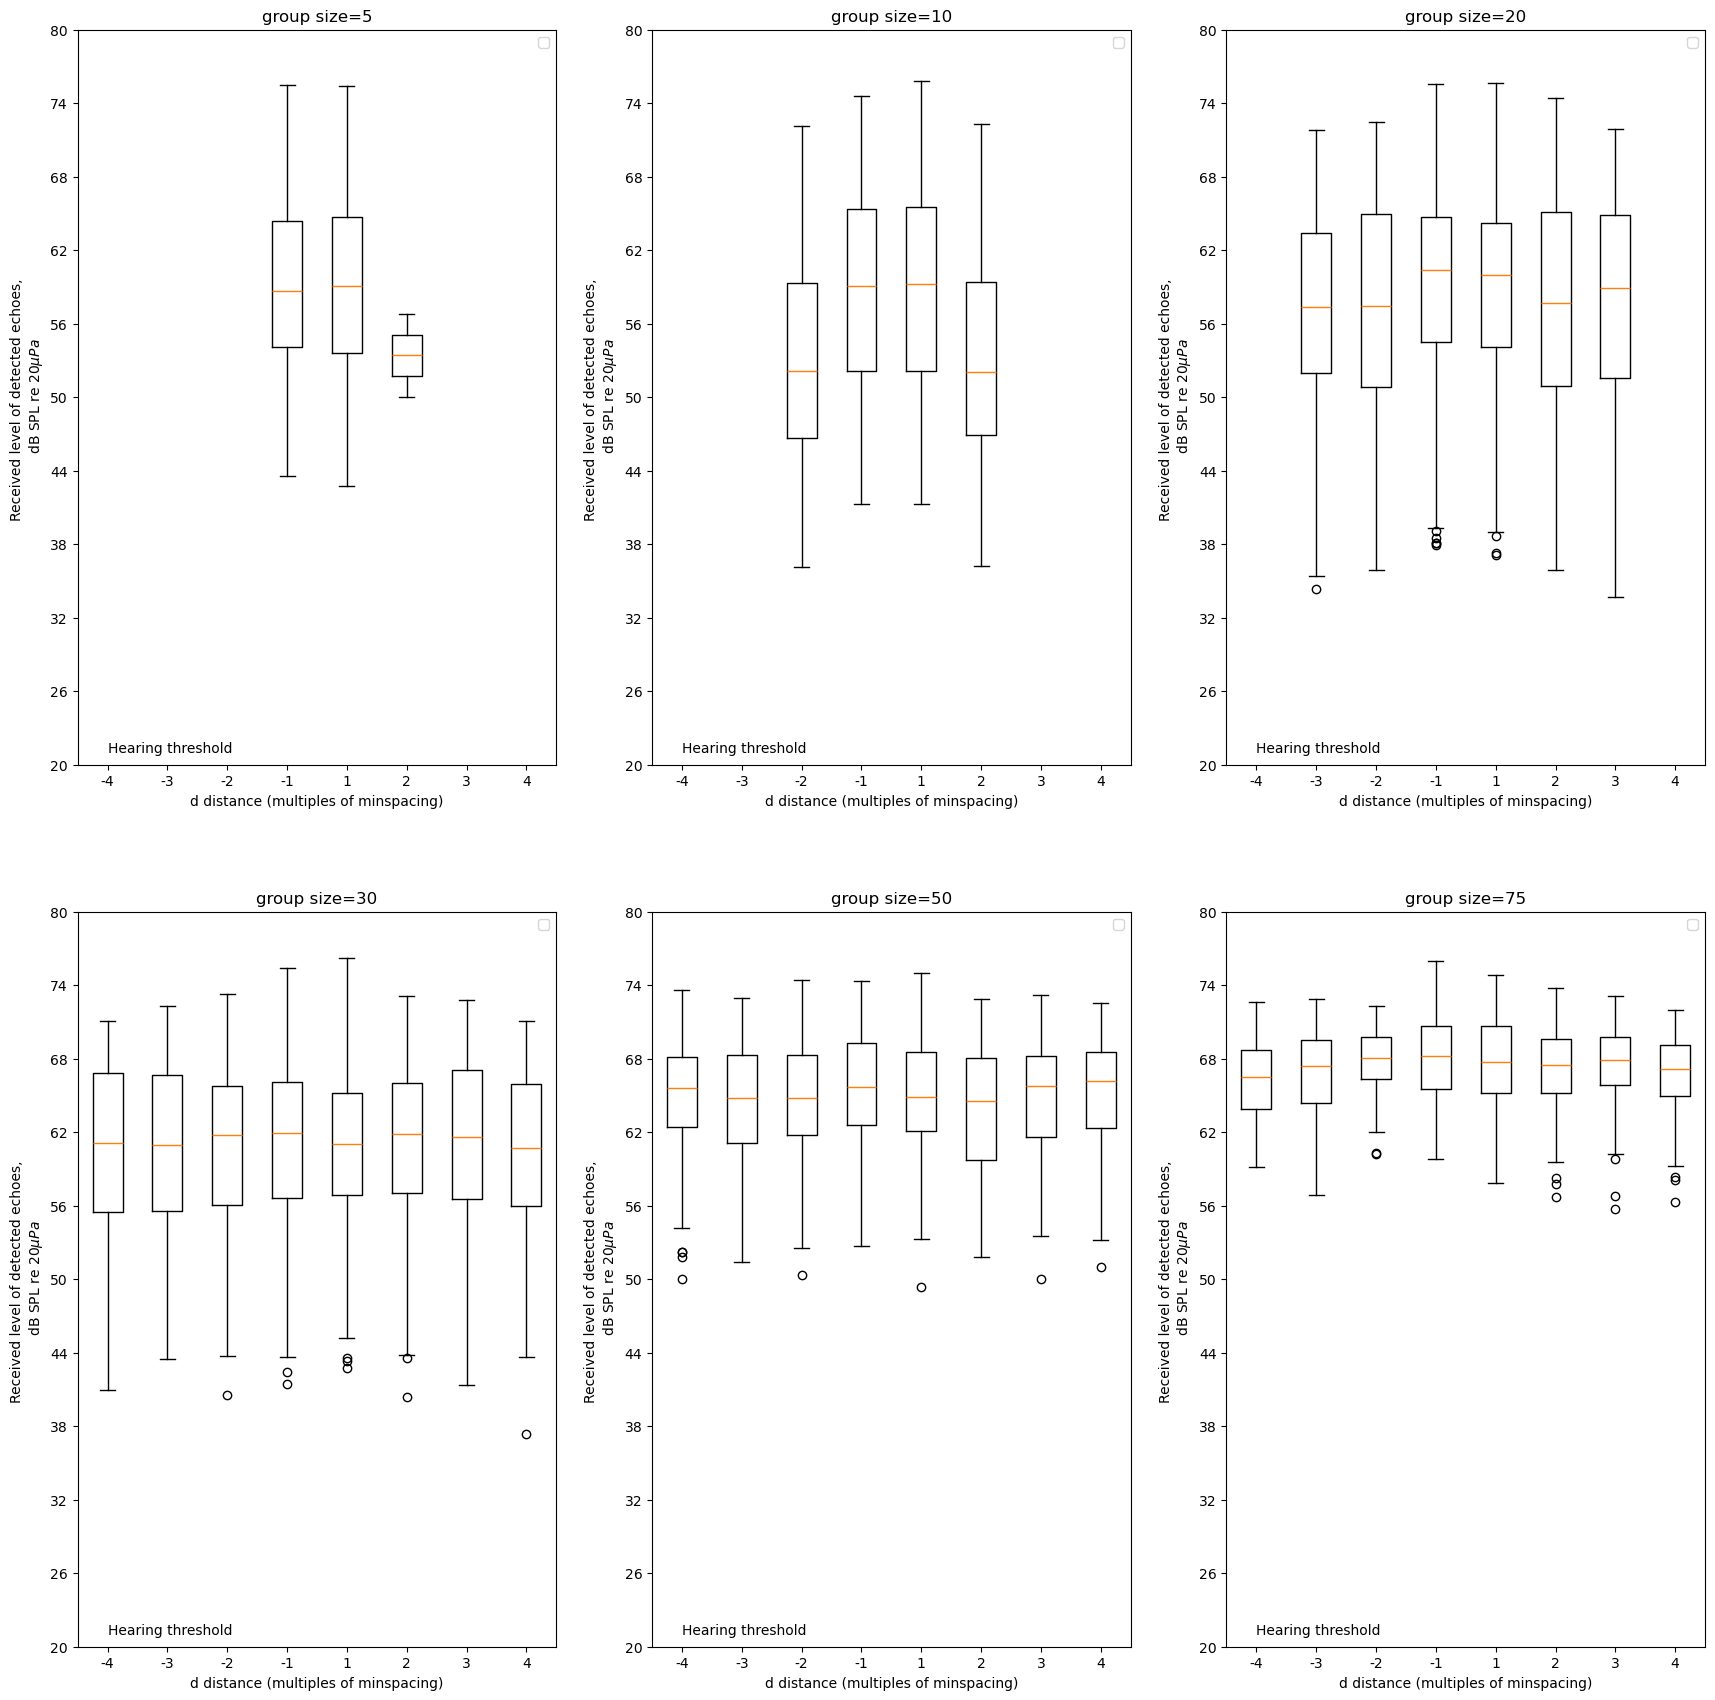

In [ ]:
i=0; 
d_distances_along_transect= [-4,-3,-2,-1,1,2,3,4]
number_of_columns=3; number_of_rows= int(np.ceil(len(group_sizes)/number_of_columns))
plt.figure(figsize= (21,21))
for group_size in group_sizes:
        array_storing_info_for_plot= []
        iterant_sign=-1
        x_ticks=[]
        for key in d_distances_along_transect:
                iterant_sign+=1
                nbrs_detected_data= store_probability_of_detection_n_neighbour[key]
                data_to_store= nbrs_detected_data['echolevels'][group_sizes.index(group_size)]
                array_storing_info_for_plot.append(data_to_store)
                x_ticks.append(key)

        plt.subplot(number_of_rows,number_of_columns,i+1)
        plt.boxplot(array_storing_info_for_plot);

        plt.ylabel('Received level of detected echoes, \n dB SPL re 20$\mu Pa$',
                                                fontsize=10)
        plt.xticks(np.arange(1,len(x_ticks)+1), x_ticks, fontsize=10)
        plt.yticks(np.arange(20,86,6),np.arange(20,86,6), fontsize=10)
        plt.text(1,21,'Hearing threshold', fontsize=10)
        plt.xlabel('d distance (multiples of minspacing)', fontsize=10)
        plt.legend()
        plt.title(f"group size={group_size}")
        print(key_for_dict)
        i+=1

-6.0
-5.0
-4.0
-3.0
-2.0
-1.0
1.0
2.0
3.0
4.0
5.0
6.0


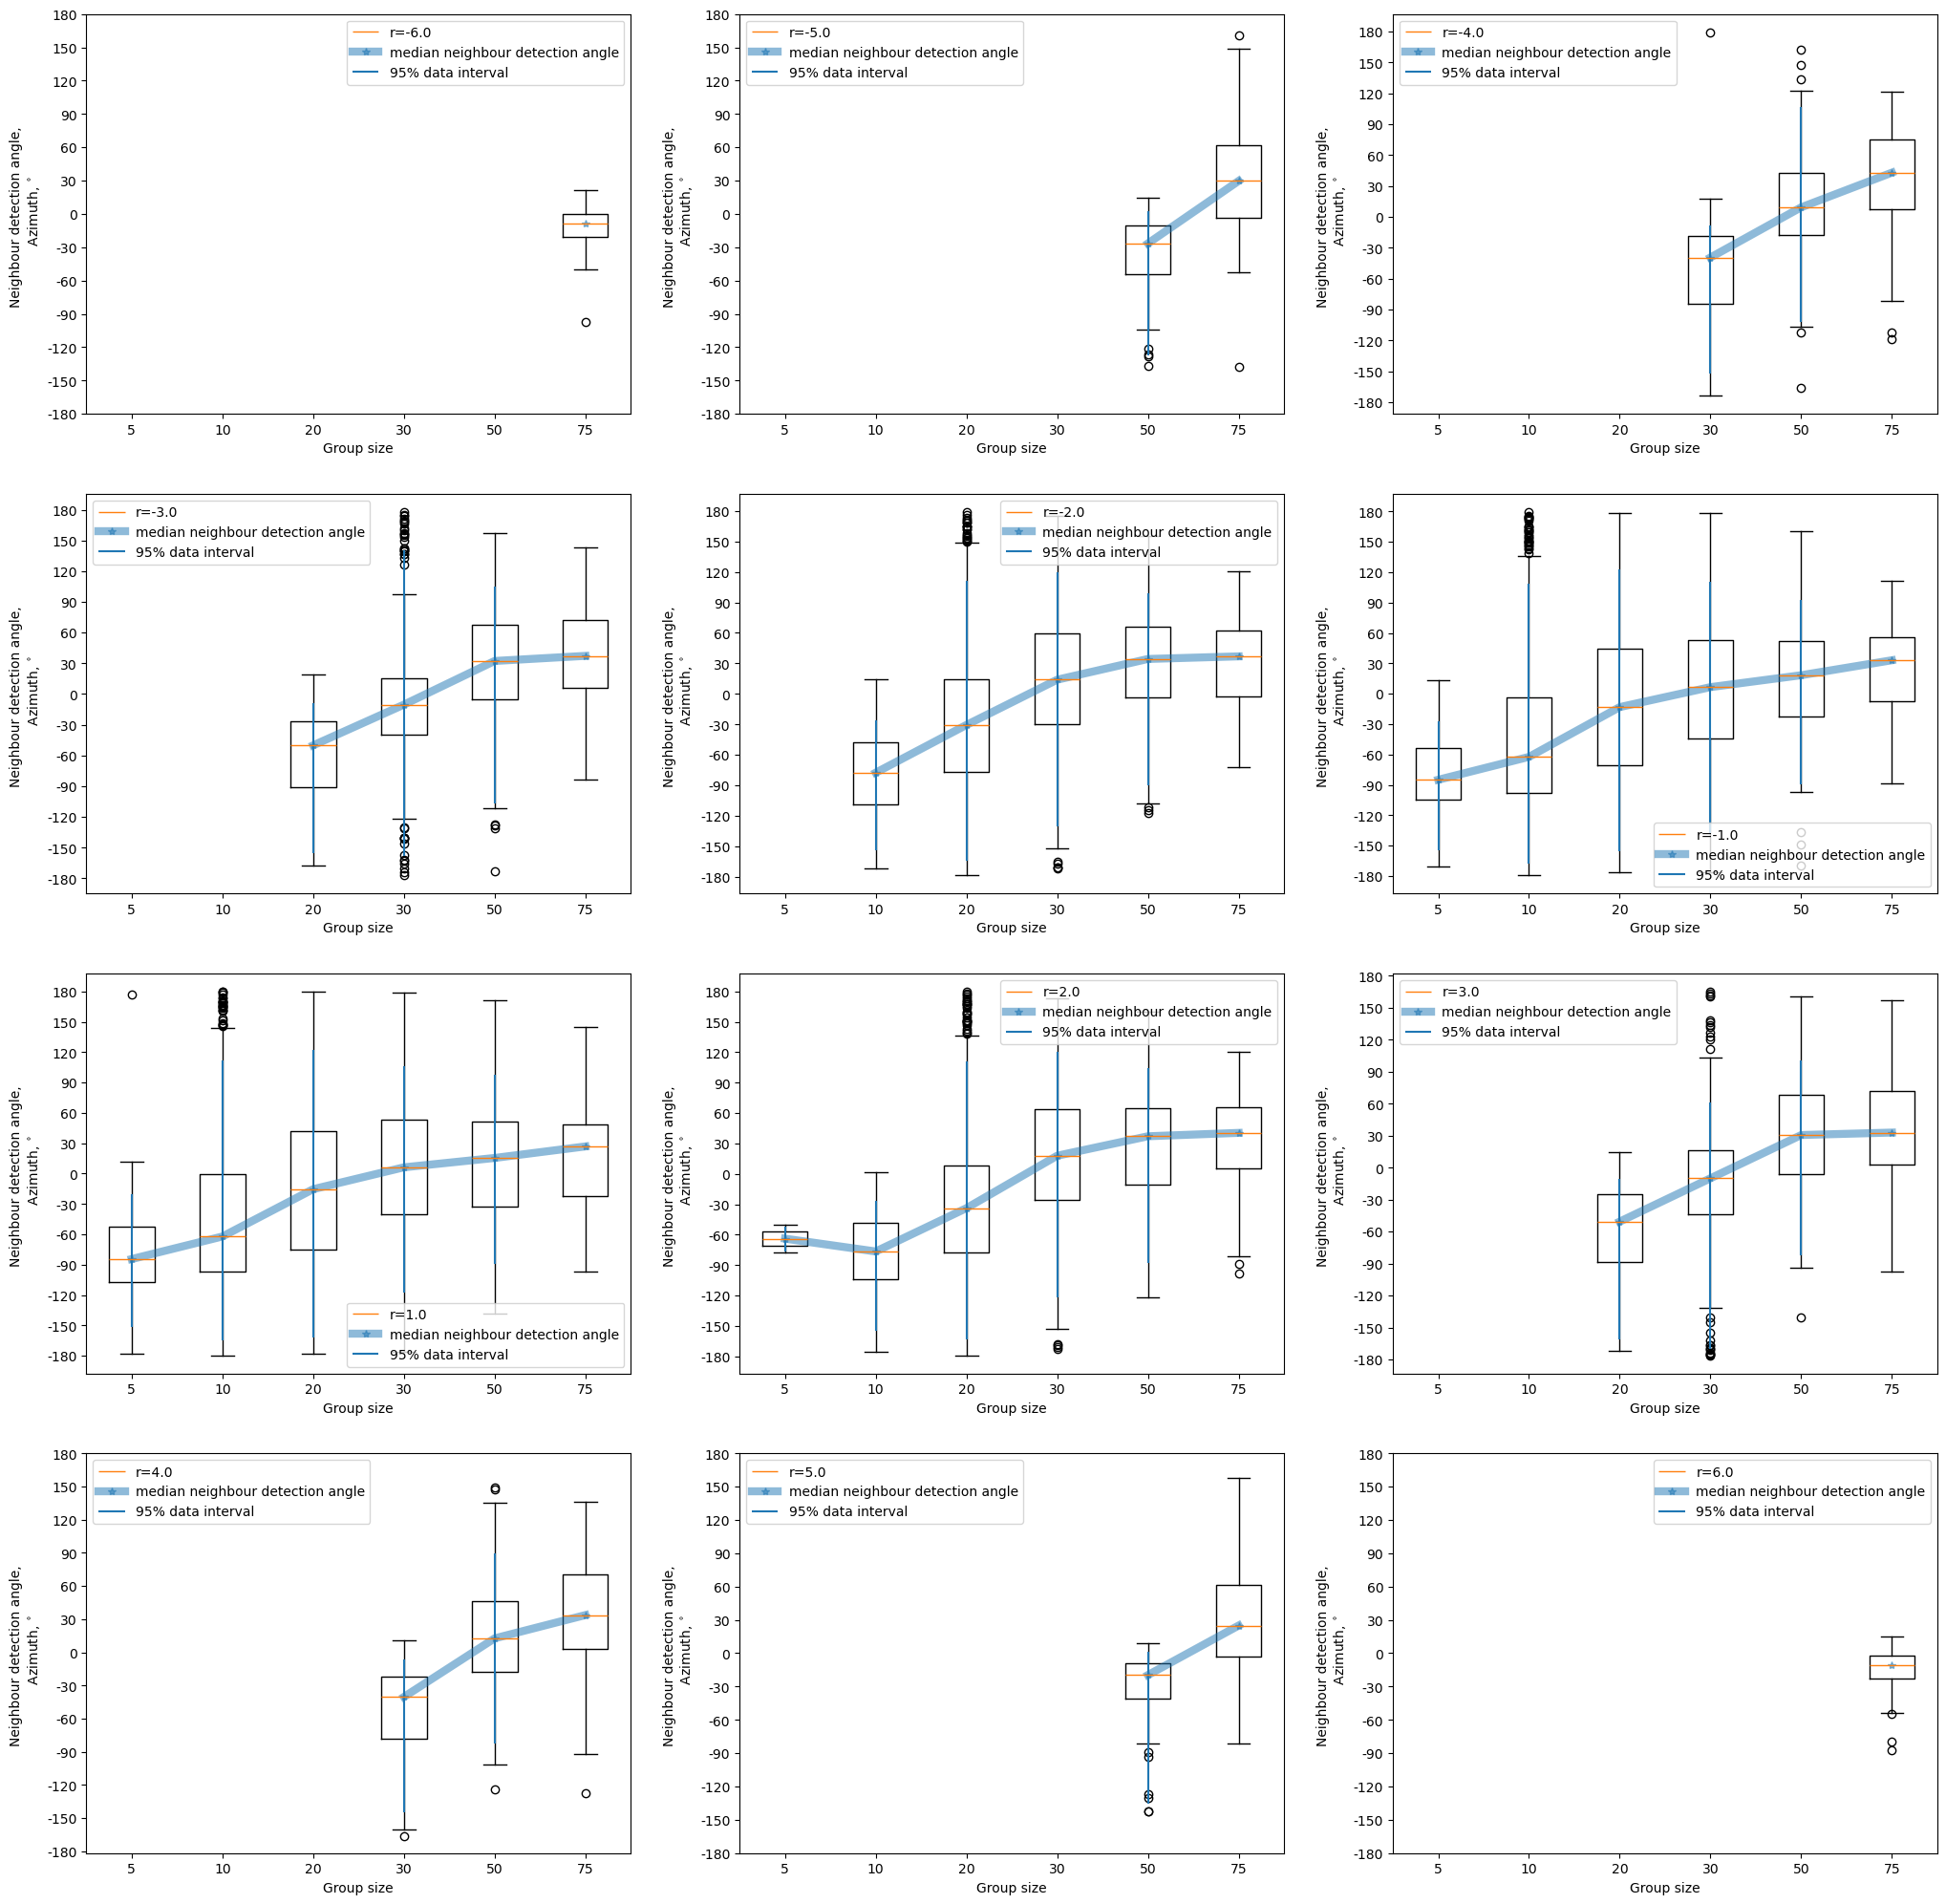

In [ ]:
i=0; 
number_of_columns=3; number_of_rows= int(np.ceil(len(sublist_of_simulation_data_intransect)/number_of_columns))
plt.figure(figsize= (25,25))
for simulation_data in sublist_of_simulation_data_intransect:
        groupsizes= group_sizes
        key_for_dict= simulation_data["focal_bat"][0][0]*sign_based_on_distance_from_centermost_point[i]
        nbrs_detected_data= store_probability_of_detection_n_neighbour[key_for_dict]

        plt.subplot(number_of_rows,number_of_columns,i+1)
        plt.boxplot(nbrs_detected_data['neighbours_azimuth'][:], label=f"r={key_for_dict}")
        plt.plot(np.arange(1,7), nbrs_detected_data['median_neighbours_azimuth'], '-*', linewidth=6,
                        alpha=0.5, label='median neighbour detection angle')
        plt.vlines(range(1,len(nbrs_detected_data['5%ile_neighbours_azimuth'])+1),nbrs_detected_data['5%ile_neighbours_azimuth'],
                nbrs_detected_data['95%ile_neighbours_azimuth'], label='95% data interval')
        #plt.plot(np.arange(1,8), nbrs_detected_data['95%ile_neighbours_azimuth'], 'g')
        #plt.plot(np.arange(1,8), nbrs_detected_data['5%ile_neighbours_azimuth'], 'g', label='95%  neighbour detection range')

        plt.yticks(np.arange(-180,210,30), np.arange(-180,210,30), fontsize=10)
        plt.xticks(np.arange(1,7), group_sizes, fontsize=10)
        plt.legend()
        plt.ylabel('Neighbour detection angle, \n  Azimuth, $^{\circ}$', fontsize=10)
        plt.xlabel('Group size', fontsize=10)


        print(key_for_dict)
        i+=1

(array([ 1.,  6.,  9., 20., 27., 42., 39., 31., 12.,  3.]),
 array([-140.3574 , -110.27132,  -80.18524,  -50.09916,  -20.01308,
          10.073  ,   40.15908,   70.24516,  100.33124,  130.41732,
         160.5034 ]),
 <BarContainer object of 10 artists>)

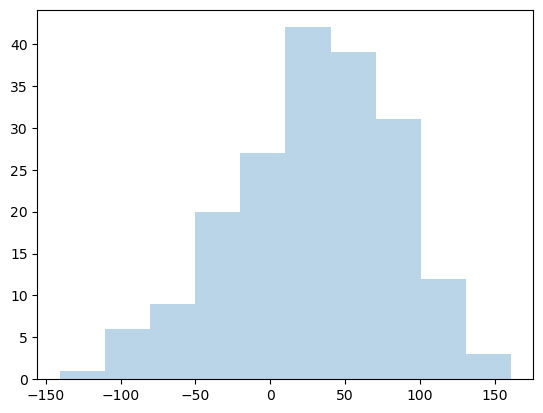

In [ ]:
nbrs_detected_data= store_probability_of_detection_n_neighbour[3]
plt.hist(nbrs_detected_data['neighbours_azimuth'][4], alpha=0.3)
# print(np.sum(plt.hist(nbrs_detected_data['neighbours_azimuth'][6])[0]))

/tmp/ipykernel_99366/2194371880.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_99366/2194371880.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_99366/2194371880.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_99366/2194371880.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_99366/2194371880.py:25: UserWarning: No artists with labels found to put in legend.  Note

6.0
6.0
6.0
6.0
6.0


/tmp/ipykernel_99366/2194371880.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


6.0


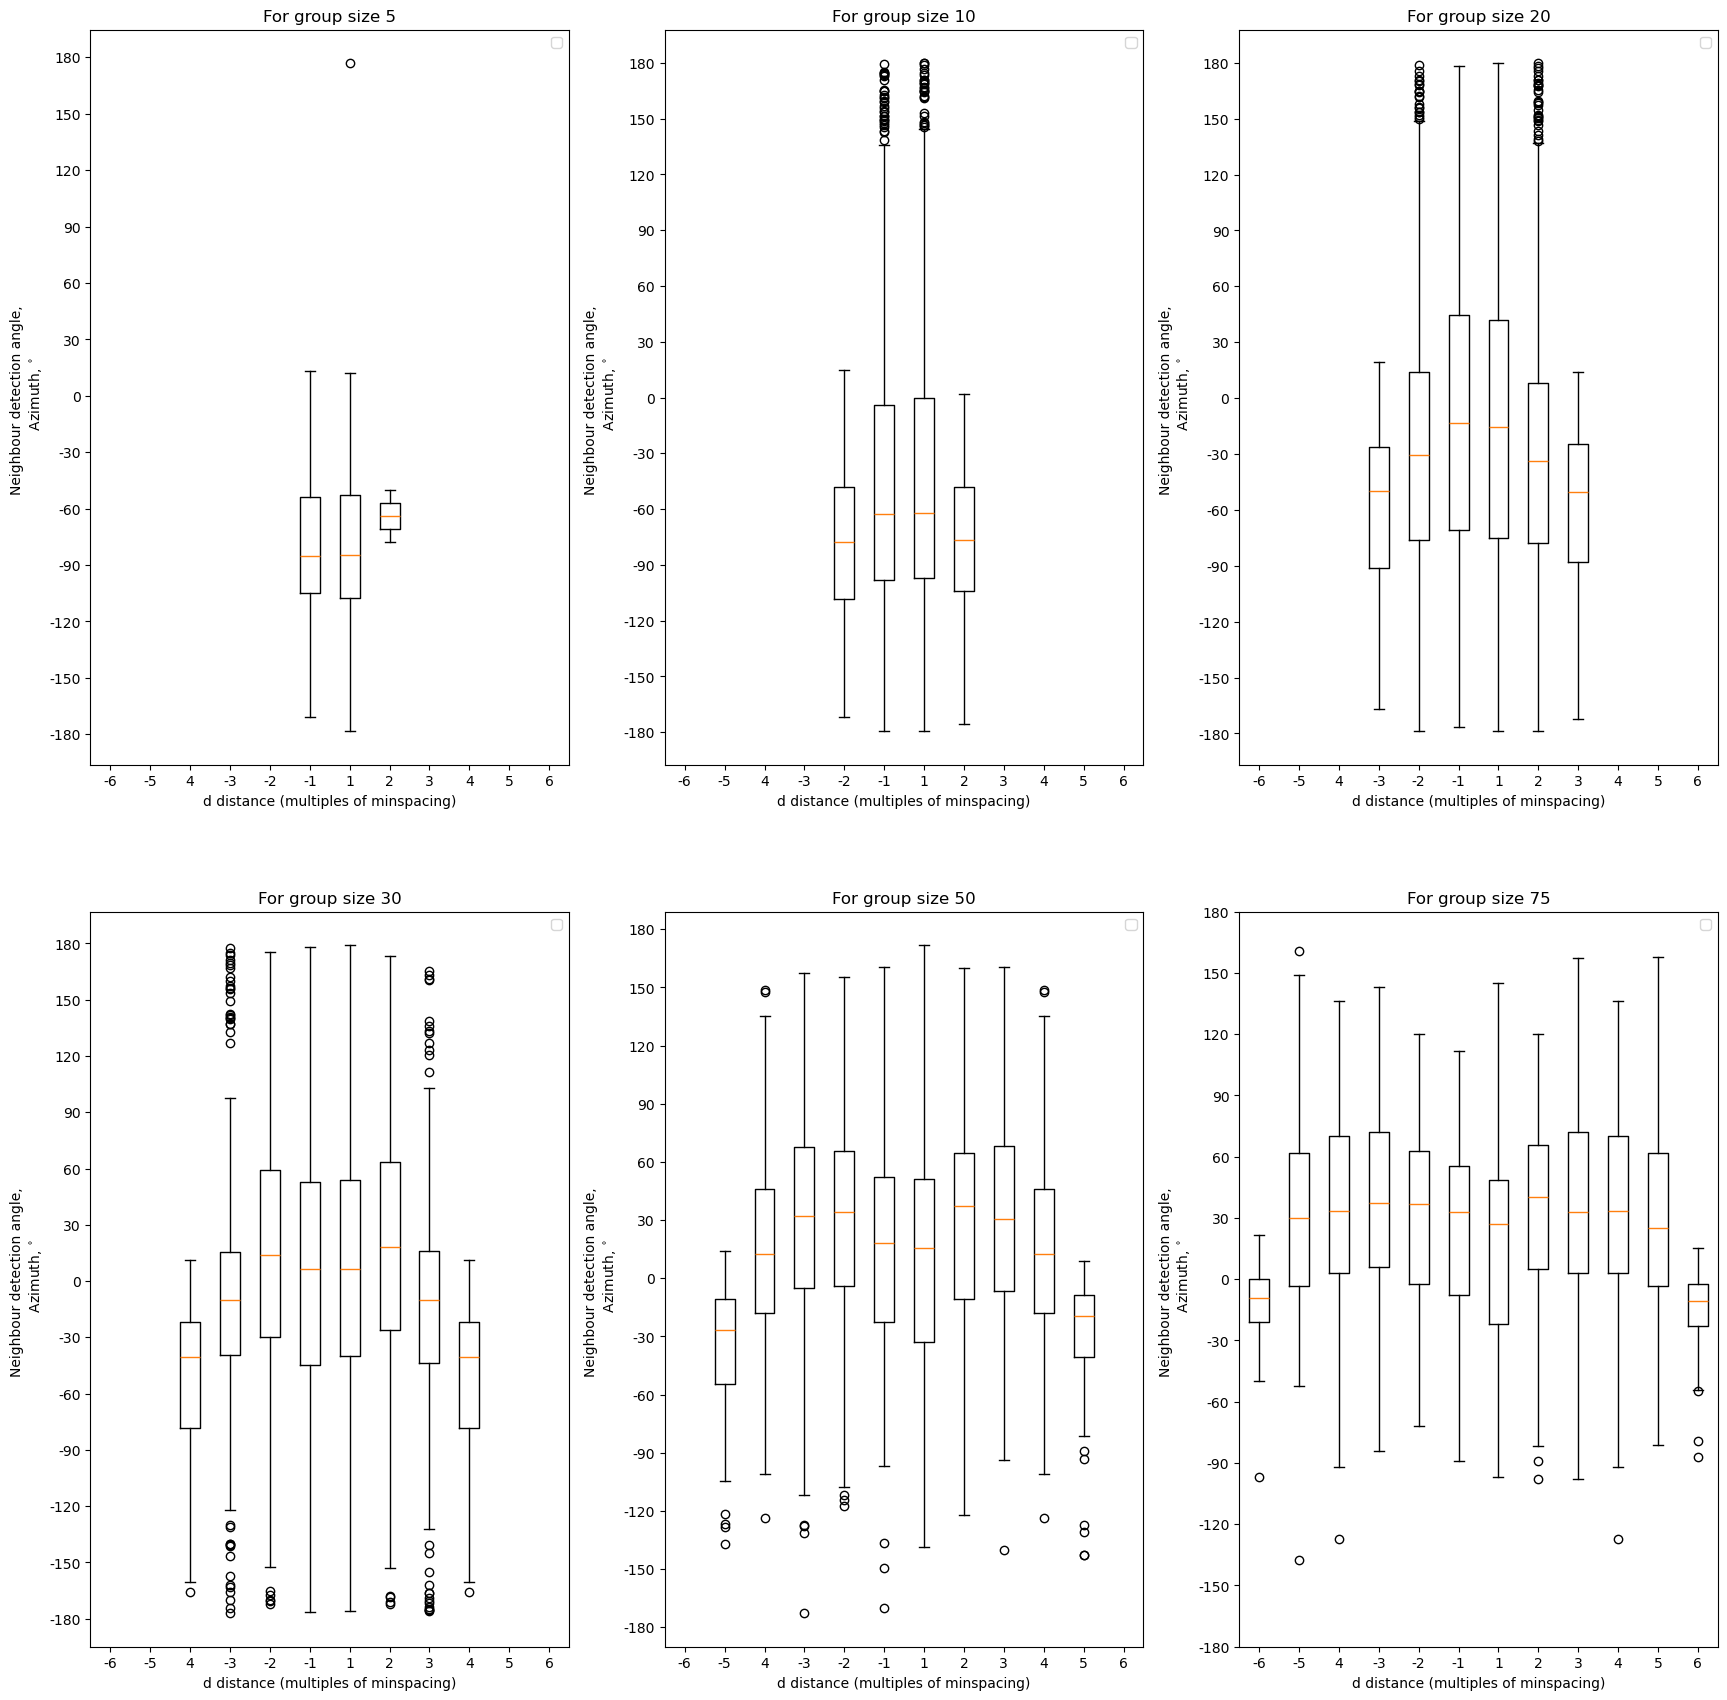

In [ ]:
i=0; 
d_distances_along_transect= [-6,-5,4,-3,-2,-1,1,2,3,4,5,6]
number_of_columns=3; number_of_rows= int(np.ceil(len(group_sizes)/number_of_columns))
plt.figure(figsize= (21,21))
for group_size in group_sizes:
        array_storing_info_for_plot= []
        iterant_sign=-1
        x_ticks=[]
        for key in d_distances_along_transect:
                iterant_sign+=1
                nbrs_detected_data= store_probability_of_detection_n_neighbour[key]
                data_to_store= nbrs_detected_data['neighbours_azimuth'][group_sizes.index(group_size)]
                array_storing_info_for_plot.append(data_to_store)
                x_ticks.append(key)

        plt.subplot(number_of_rows,number_of_columns,i+1)
        plt.boxplot(array_storing_info_for_plot);

        plt.yticks(np.arange(-180,210,30), np.arange(-180,210,30), fontsize=10)
        plt.xticks(np.arange(1,len(x_ticks)+1), x_ticks, fontsize=10)

        plt.ylabel('Neighbour detection angle, \n  Azimuth, $^{\circ}$', fontsize=10)
        plt.xlabel('d distance (multiples of minspacing)', fontsize=10)
        plt.title(f"For group size {group_size}")
        plt.legend()
        print(key_for_dict)
        i+=1

In [ ]:
class No_situation_for_given_nd(Exception):
    """Still an exception raised when uncommon things happen"""
    def __init__(self, message, payload=None):
        self.message = message
        self.payload = payload # you could add more args
    def __str__(self):
        return str(self.message)

In [ ]:
try:
    raise No_situation_for_given_nd(f"Failure to generate scenario in which there exists no point that is {1} number of step(s) away from the centermost bat")
except No_situation_for_given_nd as error:
    print(str(error)) # Very bad mistake
print("omg")

Failure to generate scenario in which there exists no point that is 1 number of step(s) away from the centermost bat
omg


In [ ]:
simulation_data.keys()

Index(['nbrs_detected', 'group_size', 'group_diameter',
       'nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid', 'seed',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth',
       'heading_variation', 'echocall_duration', 'atmospheric_attenuation',
       'min_spacing', 'source_level', 'interpulse_interval',
       'implement_shadowing', 'focal_bat'],
      dtype='object')

In [ ]:
nbrs_detected_data.keys()

dict_keys(['group_sizes', 'num_nbrs', 'median_num_nbrs', '90%ile_num_nbrs', '0neighbours', 'geq_1neighbour', 'geq_2neighbour', 'geq_3neighbour', 'geq_4neighbour', 'detected_distances', 'median_detected_distances', '90%ile_detected_distances', 'neighbours_azimuth', 'median_neighbours_azimuth', '95%ile_neighbours_azimuth', '5%ile_neighbours_azimuth', 'echolevels', 'median_echolevels', '5%ile_echolevels', '95%ile_echolevels'])

In [ ]:
nbrs_detected_data

{'group_sizes': [5, 10, 20, 30, 50, 75],
 'num_nbrs': [nan,
  nan,
  nan,
  nan,
  nan,
  array([0, 0, 1, 0, 1, 1, 1, 2, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0,
         0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 2, 0, 1, 0, 1, 0, 0, 1, 1, 1,
         1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
         1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
         1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0])],
 'median_num_nbrs': [nan, nan, nan, nan, nan, np.float64(0.0)],
 '90%ile_num_nbrs': [nan, nan, nan, nan, nan, np.float64(1.0)],
 '0neighbours': [nan, nan, nan, nan, nan, np.float64(0.53)],
 'geq_1neighbour': [nan, nan, nan, nan, nan, np.float64(0.47)],
 'geq_2neighbour': [nan, nan, nan, nan, nan, np.float64(0.02)],
 'geq_3neighbour': [nan, nan, nan, nan, nan, np.float64(0.0)],
 'geq_4neighbour': [nan, nan, nan, nan, nan, np.float64(0.0)],
 'detected_distances': [nan,
  nan,
  nan,
  nan,
  nan,
  array([0.58745907, 0.50073516, 0.7851152 , 0.61386692, 0.52964

In [162]:
def modify_dict_for_seaborn(input_dict,key_x,key_y):
    radial_dist= input_dict.keys()
    x,y,hue= [], [], []
    for r in radial_dist:
        data_to_plotted= input_dict[r]
        y_axis_raw= data_to_plotted[key_y]
        x_axis_raw= data_to_plotted[key_x]
        # print(x_axis_raw)
        for index_group_sizes in range(len(x_axis_raw)):
            group_size= x_axis_raw[index_group_sizes]
            y_corresponding_to_group_size= y_axis_raw[index_group_sizes]
            # print(y_corresponding_to_group_size)
            for entry in y_corresponding_to_group_size:
                # print(entry)
                y.append(entry)
                x.append(group_size)
                hue.append(r)

    return x,y,hue

<Axes: >

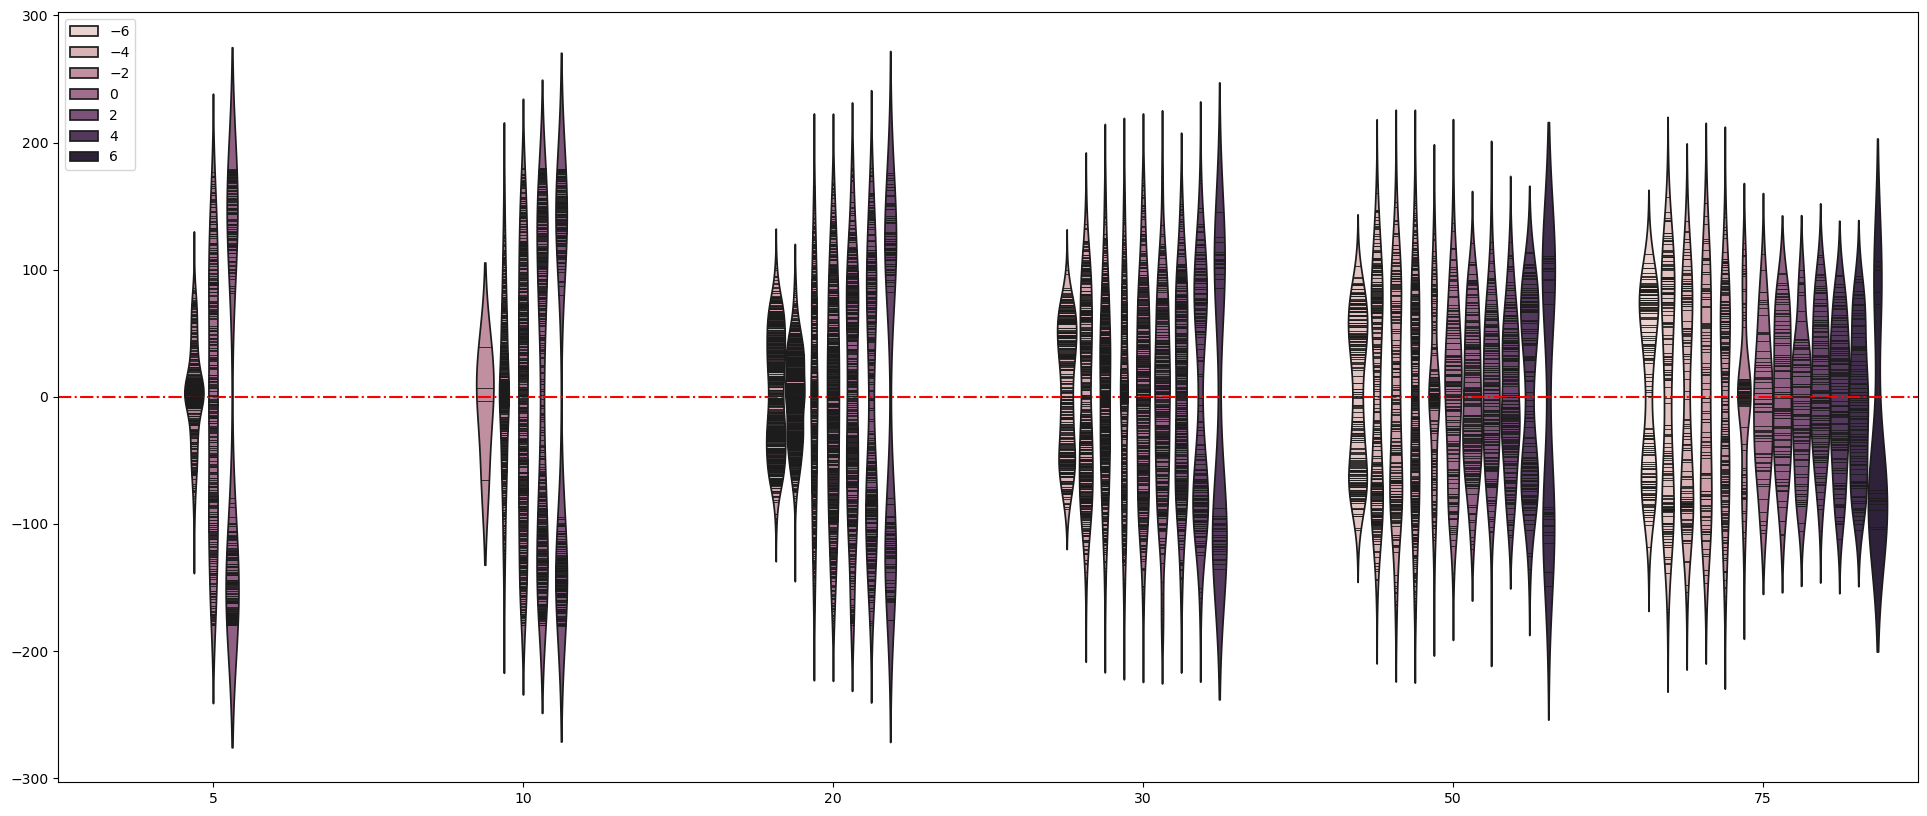

In [187]:
import seaborn as sns
from matplotlib.collections import PathCollection
x,y,hue= modify_dict_for_seaborn(store_probability_of_detection_n_neighbour, "group_sizes", "neighbours_azimuth")
plt.figure(figsize=(24,10))
plt.axhline(0, ls= "-.", color="red")
sns.violinplot(x=x, y=y, hue=hue, inner="stick", hue_order=store_probability_of_detection_n_neighbour.keys())
# sns.swarmplot(x=x, y=y, hue=hue)
# plt.title("neighbour azimuth across groupsize for heading var= "+ str(heading_var))

In [189]:
counter=0; array= []
for i in range(len(x)):
    if x[i]==10 and hue[i]==-2:
        array.append(y[i])
        counter+=1
counter
# plt.hist(array)

4

<Axes: >

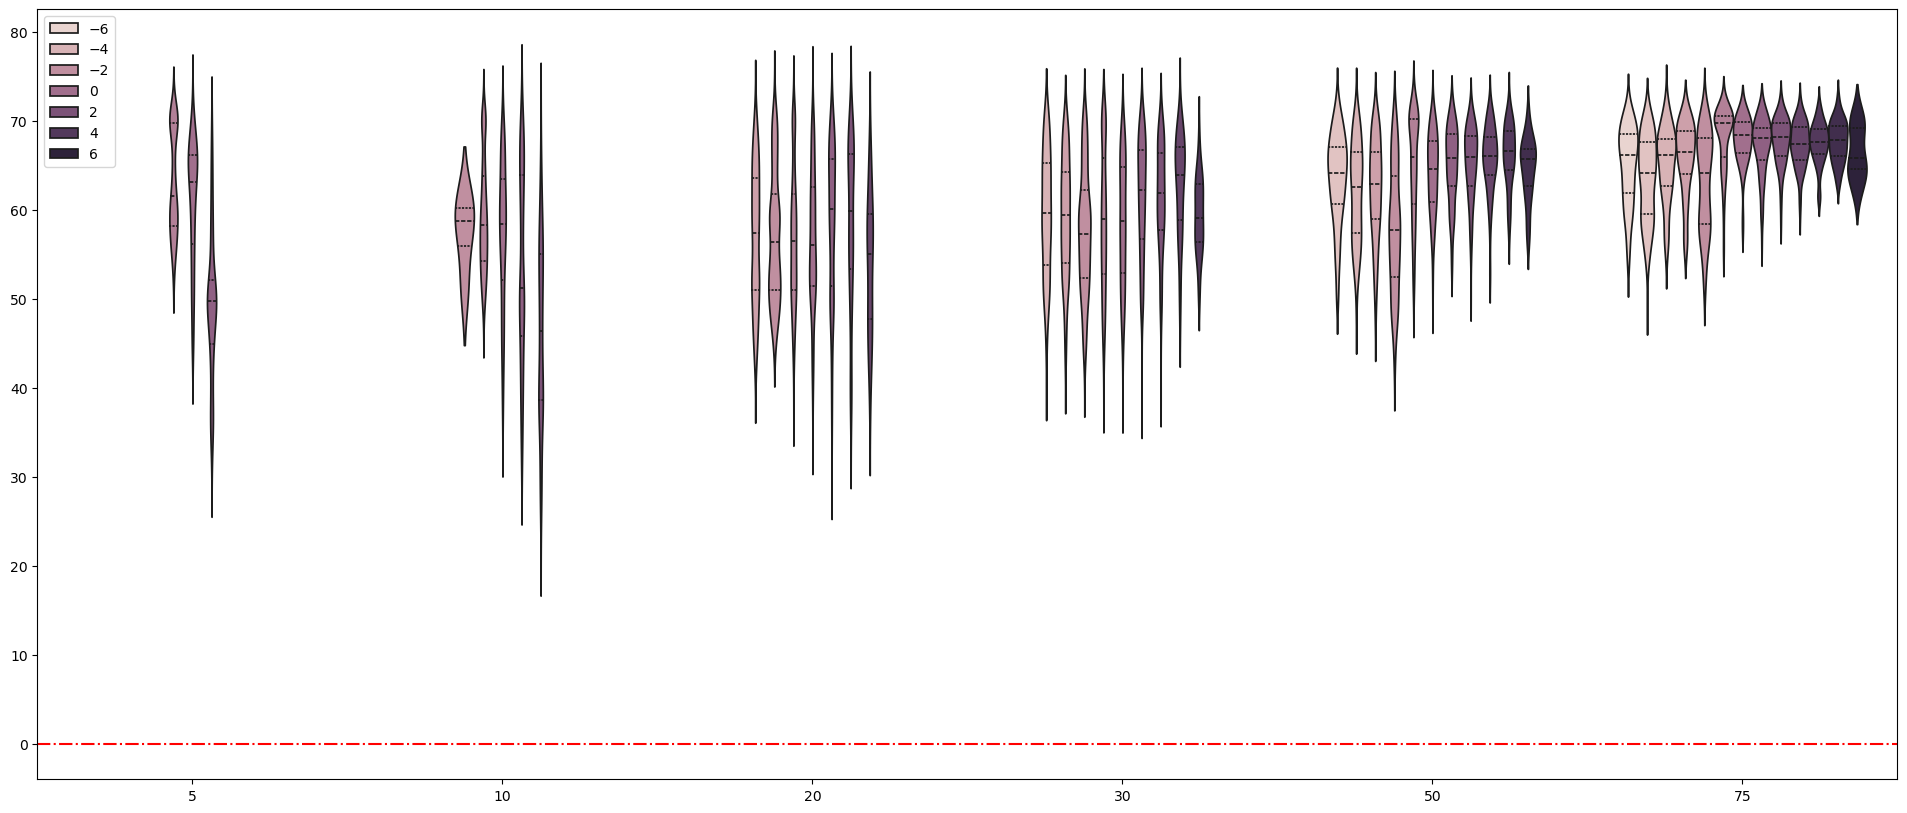

In [165]:
import seaborn as sns
x,y,hue= modify_dict_for_seaborn(store_probability_of_detection_n_neighbour, "group_sizes", "echolevels")
plt.figure(figsize=(24,10))
plt.axhline(0, ls= "-.", color="red")
sns.violinplot(x=x, y=y, hue=hue, inner="quart", hue_order=store_probability_of_detection_n_neighbour.keys())
# plt.title("neighbour azimuth across groupsize for heading var= "+ str(heading_var))